In [11]:
from data_loader import describe_columns, load
from eda import run_full_eda
from preprocessing import process, make_agg_series
from anomaly import detect
from features import build, train_test_split
from models import (
    arima_model, prophet_model, linear_model,
    rf_model, xgb_model, lstm_model, adaboost_model
)
from metrics import evaluate, summary_table
from visualization import plot_forecasts, plot_residuals, plot_metrics_heatmap, plot_metrics_bars, plot_feature_importance_comparison, plot_dashboard
print('✓ Все модули загружены')

✓ Все модули загружены


In [ ]:
# data_loader.py


import pandas as pd
from pathlib import Path


# ── Описание колонок ─────────────────────────────────────────

COLUMN_DESCRIPTIONS = {
    # sales_train_validation.csv
    "id":           "Уникальный ID товара (item_dept_cat_store_state_validation)",
    "item_id":      "ID товара (напр. HOBBIES_1_001)",
    "dept_id":      "ID отдела (напр. HOBBIES_1)",
    "cat_id":       "Категория: HOBBIES / HOUSEHOLD / FOODS",
    "store_id":     "ID магазина (напр. CA_1)",
    "state_id":     "Штат: CA / TX / WI",
    "d_1..d_1913":  "Ежедневные продажи в штуках (d_1 = 2011-01-29)",
    # calendar.csv
    "date":         "Дата",
    "wm_yr_wk":     "Неделя в формате Walmart",
    "weekday":      "День недели (строка)",
    "wday":         "День недели (1=воскресенье)",
    "month":        "Месяц",
    "year":         "Год",
    "event_name_1": "Название праздника/события 1",
    "event_type_1": "Тип события 1 (Cultural/National/Religious/Sporting)",
    "event_name_2": "Название события 2 (если есть)",
    "event_type_2": "Тип события 2",
    "snap_CA/TX/WI":"Флаг SNAP (программа продовольственных талонов) по штату",
    # sell_prices.csv
    "sell_price":   "Цена товара в данном магазине на данной неделе",
}


def describe_columns() -> None:
    """Печатает описание всех колонок датасета M5."""
    print(f"\n{'Колонка':<22} {'Описание'}")
    print("─" * 75)
    for col, desc in COLUMN_DESCRIPTIONS.items():
        print(f"  {col:<20} {desc}")


def load(data_dir: str = "data",
         store_id: str = "CA_1",
         aggregate: bool = True) -> dict:
    """
    Загружает файлы M5 и возвращает словарь датафреймов.

    Parameters
    ----------
    data_dir  : папка с CSV-файлами от Kaggle
    store_id  : фильтр по магазину (None = все магазины)
    aggregate : если True — суммирует продажи по всем товарам магазина
                в один ряд

    Returns
    -------
    dict с ключами: 'sales', 'calendar', 'prices', 'ts'
      sales    — исходные данные по товарам (wide format)
      calendar — календарь событий и SNAP
      prices   — цены товаров
      ts       — готовый временной ряд (long format, merged)
    """
    data_dir = Path(data_dir)

    print("Загрузка файлов M5...")
    sales    = pd.read_csv(data_dir / "sales_train_validation.csv")
    calendar = pd.read_csv(data_dir / "calendar.csv")
    prices   = pd.read_csv(data_dir / "sell_prices.csv")

    # Фильтр по магазину
    if store_id:
        sales  = sales[sales["store_id"] == store_id].reset_index(drop=True)
        prices = prices[prices["store_id"] == store_id].reset_index(drop=True)
        print(f"  Магазин: {store_id}  |  товаров: {len(sales)}")

    print(f"  Дней: {sales.shape[1] - 6}  |  Календарь: {len(calendar)} строк")

    # Преобразуем в long format
    day_cols  = [c for c in sales.columns if c.startswith("d_")]
    meta_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

    sales_long = sales.melt(
        id_vars=meta_cols,
        value_vars=day_cols,
        var_name="d",
        value_name="sales",
    )

    # Присоединяем календарь
    ts = sales_long.merge(
        calendar[["d", "date", "wm_yr_wk", "wday", "month", "year",
                  "event_name_1", "event_type_1",
                  "event_name_2", "event_type_2",
                  "snap_CA", "snap_TX", "snap_WI"]],
        on="d", how="left"
    )
    ts["date"] = pd.to_datetime(ts["date"])

    # Присоединяем цены
    ts = ts.merge(
        prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]],
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left"
    )

    if aggregate:
        # Агрегируем: суммарные продажи по магазину на каждый день
        ts_agg = (
            ts.groupby("date")
            .agg(sales=("sales", "sum"),
                 avg_price=("sell_price", "mean"),
                 event=("event_name_1", lambda x: x.notna().any().astype(int)))
            .reset_index()
            .set_index("date")
            .sort_index()
        )
        print(f"  ✓ Агрегированный ряд: {len(ts_agg)} дней")
        return {"sales": sales, "calendar": calendar,
                "prices": prices, "ts": ts, "ts_agg": ts_agg}

    ts = ts.sort_values(["item_id", "date"]).reset_index(drop=True)
    print(f"  ✓ Long format: {len(ts):,} строк")
    return {"sales": sales, "calendar": calendar, "prices": prices, "ts": ts}

In [ ]:
# eda.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2"]


def plot_hierarchy(data: dict, save: bool = False) -> None:
    """Иерархическая структура датасета: категории и отделы."""
    sales = data["sales"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, col, title in zip(
        axes,
        ["cat_id", "dept_id"],
        ["По категориям", "По отделам"]
    ):
        counts = sales[col].value_counts()
        counts.plot(kind="bar", ax=ax, color=PALETTE[:len(counts)], edgecolor="none")
        ax.set_title(f"Кол-во товаров: {title}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    plt.suptitle("Иерархическая структура Walmart M5", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("eda_hierarchy.png", dpi=120)
    plt.show()


def plot_aggregate_sales(ts_agg: pd.DataFrame, save: bool = False) -> None:
    """Агрегированный ряд продаж магазина: дневной + недельный."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 11))

    # ── 1. Недельные продажи (читаемо) ───────────────────────
    weekly = ts_agg["sales"].resample("W").sum()
    ma_12w = weekly.rolling(12).mean()
    axes[0].bar(weekly.index, weekly.values,
                color=PALETTE[0], alpha=0.5, width=5, label="Недельные продажи")
    axes[0].plot(weekly.index, ma_12w,
                 color=PALETTE[1], linewidth=1.5, label="MA-12 недель")
    axes[0].set_title("Суммарные продажи магазина (по неделям)")
    axes[0].set_ylabel("Продажи, шт.")
    axes[0].legend()

    # ── 2. Дневные продажи с MA ───────────────────────────────
    ma30 = ts_agg["sales"].rolling(30).mean()
    axes[1].plot(ts_agg.index, ts_agg["sales"],
                 color=PALETTE[0], linewidth=0.6, alpha=0.5, label="Дневные продажи")
    axes[1].plot(ts_agg.index, ma30,
                 color=PALETTE[1], linewidth=1.5, label="MA-30 дней")
    # События
    event_days = ts_agg[ts_agg["event"] == 1].index
    axes[1].scatter(event_days, ts_agg.loc[event_days, "sales"],
                    color=PALETTE[2], s=15, zorder=5, label="Событие", alpha=0.7)
    axes[1].set_title("Суммарные продажи магазина (дневные)")
    axes[1].set_ylabel("Продажи, шт.")
    axes[1].legend()

    # ── 3. Средняя цена ───────────────────────────────────────
    axes[2].plot(ts_agg.index, ts_agg["avg_price"],
                 color=PALETTE[3], linewidth=0.8)
    axes[2].set_title("Средняя цена товара")
    axes[2].set_ylabel("Цена, $")
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.tight_layout()
    if save:
        plt.savefig("eda_aggregate_sales.png", dpi=120)
    plt.show()


def plot_seasonality(ts_agg: pd.DataFrame, save: bool = False) -> None:
    """Сезонность: суммарные продажи по дням недели и по месяцам."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # По дням недели (0=Пн .. 6=Вс)
    day_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
    by_wday = ts_agg["sales"].groupby(ts_agg.index.dayofweek).mean()
    axes[0].bar(by_wday.index, by_wday.values,
                color=PALETTE[:len(by_wday)], edgecolor="none")
    axes[0].set_xticks(by_wday.index)
    axes[0].set_xticklabels(day_names)
    axes[0].set_title("Средние продажи по дням недели")
    axes[0].set_ylabel("Продажи, шт.")

    # По месяцам
    by_month = ts_agg["sales"].groupby(ts_agg.index.month).mean()
    month_names = ["Янв","Фев","Мар","Апр","Май","Июн",
                   "Июл","Авг","Сен","Окт","Ноя","Дек"]
    axes[1].bar(by_month.index, by_month.values,
                color=PALETTE[2], edgecolor="none", alpha=0.85)
    axes[1].set_xticks(by_month.index)
    axes[1].set_xticklabels(month_names, rotation=30)
    axes[1].set_title("Средние продажи по месяцам")
    axes[1].set_ylabel("Продажи, шт.")

    plt.suptitle("Сезонность продаж", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("eda_seasonality.png", dpi=120)
    plt.show()


def plot_event_impact(ts: pd.DataFrame, save: bool = False) -> None:
    """Влияние событий и SNAP на продажи."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # SNAP vs no SNAP (берём штат CA как пример)
    snap_col = "snap_CA"
    if snap_col in ts.columns:
        snap_sales = ts.groupby(snap_col)["sales"].mean()
        axes[0].bar(["Обычный день", "SNAP день"],
                    snap_sales.values,
                    color=[PALETTE[0], PALETTE[2]], edgecolor="none")
        axes[0].set_title("Продажи: обычный vs SNAP день (CA)")
        axes[0].set_ylabel("Средние продажи, шт.")

    # События по типу
    ts_ev = ts[ts["event_type_1"].notna()].copy()
    if len(ts_ev) > 0:
        by_event = ts_ev.groupby("event_type_1")["sales"].mean().sort_values()
        no_event  = ts[ts["event_type_1"].isna()]["sales"].mean()
        all_vals  = pd.concat([by_event,
                               pd.Series({"Нет события": no_event})])
        colors = [PALETTE[1] if k != "Нет события" else PALETTE[4]
                  for k in all_vals.index]
        axes[1].barh(all_vals.index, all_vals.values,
                     color=colors, edgecolor="none")
        axes[1].set_title("Средние продажи по типу события")
        axes[1].set_xlabel("Продажи, шт.")

    plt.suptitle("Влияние событий и SNAP", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("eda_events.png", dpi=120)
    plt.show()


def plot_zero_sales(ts: pd.DataFrame, save: bool = False) -> None:
    """Доля нулевых продаж по товарам."""
    zero_pct = (
        ts.groupby("item_id")["sales"]
        .apply(lambda x: (x == 0).mean() * 100)
    )
    median_val = zero_pct.median()
    over50 = (zero_pct > 50).sum()
    over90 = (zero_pct > 90).sum()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(zero_pct, bins=40, color=PALETTE[0], edgecolor="none", alpha=0.85)

    ax.axvline(median_val, color=PALETTE[1], linestyle="--",
               linewidth=1.5, label=f"Медиана: {median_val:.1f}%")

    # Аннотации зон
    ax.axvspan(0,  50, alpha=0.05, color=PALETTE[2],
               label=f"< 50% нулей: {(zero_pct <= 50).sum()} товаров (продаются часто)")
    ax.axvspan(50, 100, alpha=0.05, color=PALETTE[1],
               label=f"> 50% нулей: {over50} товаров (продаются редко)")

    ax.annotate(f"{over90} товаров\nне продаются\n>90% времени",
                xy=(93, ax.get_ylim()[1] * 0.5),
                fontsize=9, color=PALETTE[1],
                ha="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

    ax.set_title("Доля нулевых продаж по товарам\n"
                 "(0% = товар продаётся каждый день, 100% = никогда не продаётся)")
    ax.set_xlabel("% дней без продаж")
    ax.set_ylabel("Кол-во товаров")
    ax.legend(fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig("eda_zeros.png", dpi=120)
    plt.show()

    print(f"  Медиана нулевых продаж: {median_val:.1f}%")
    print(f"  Товаров с >50% нулей:   {over50} из {len(zero_pct)}")
    print(f"  Товаров с >90% нулей:   {over90} — редкие товары")
    print(f"  Вывод: агрегация по магазину устраняет проблему нулей")


def stationarity_tests(series: pd.Series, name: str = "series") -> dict:
    """ADF и KPSS тесты для временного ряда."""
    s = series.dropna()
    adf = adfuller(s)
    kpss_res = kpss(s, regression="c", nlags="auto")

    print(f"\n── ADF тест [{name}] ─────────────────────")
    print(f"  Statistic : {adf[0]:.4f}  |  p-value: {adf[1]:.6f}")
    print(f"  Вывод     : {'Стационарный ✓' if adf[1] < 0.05 else 'НЕ стационарный ✗'}")

    print(f"\n── KPSS тест [{name}] ────────────────────")
    print(f"  Statistic : {kpss_res[0]:.4f}  |  p-value: {kpss_res[1]:.4f}")
    print(f"  Вывод     : {'Стационарный ✓' if kpss_res[1] > 0.05 else 'НЕ стационарный ✗'}")

    return {"adf": adf, "kpss": kpss_res}


def plot_decomposition(series: pd.Series,
                       period: int = 7,
                       save: bool = False):
    """Декомпозиция временного ряда — кастомный стиль."""
    from statsmodels.tsa.seasonal import STL
    stl = STL(series.dropna(), period=period, robust=True)
    result = stl.fit()

    # Недельная агрегация для читаемости тренда и остатка
    trend_w    = result.trend.resample("W").mean()
    seasonal_w = result.seasonal.resample("W").mean()
    resid_w    = result.resid.resample("W").mean()

    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    fig.suptitle(f"STL-декомпозиция продаж (период={period} дней)",
                 fontsize=13, fontweight="bold", y=1.01)

    # 1. Исходный ряд (недельный для читаемости)
    sales_w = series.resample("W").sum()
    axes[0].plot(sales_w.index, sales_w.values,
                 color=PALETTE[0], linewidth=1)
    axes[0].set_title("Исходный ряд (недельные продажи)")
    axes[0].set_ylabel("Продажи, шт.")

    # 2. Тренд
    axes[1].plot(trend_w.index, trend_w.values,
                 color=PALETTE[4], linewidth=1.5)
    axes[1].set_title("Тренд — общее направление роста/падения")
    axes[1].set_ylabel("Продажи, шт.")

    # 3. Сезонность — показываем только 3 месяца чтобы был виден паттерн
    seasonal_zoom = result.seasonal.iloc[:90]
    axes[2].fill_between(seasonal_zoom.index, seasonal_zoom.values,
                         color=PALETTE[2], alpha=0.6)
    axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[2].set_title("Сезонность — недельный паттерн (первые 90 дней)")
    axes[2].set_ylabel("Отклонение")

    # 4. Остаток (шум)
    axes[3].bar(resid_w.index, resid_w.values,
                color=PALETTE[1], alpha=0.6, width=5)
    axes[3].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[3].set_title("Остаток — необъяснённый шум (праздники, аномалии)")
    axes[3].set_ylabel("Отклонение")

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.tick_params(axis="x", rotation=20)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    if save:
        plt.savefig("eda_decomposition.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Возвращаем result для дашборда
    return result


def plot_acf_pacf(series: pd.Series, lags: int = 40, save: bool = False) -> None:
    """ACF и PACF для ряда продаж."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series.dropna(),  lags=lags, ax=axes[0], title="ACF продаж")
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], title="PACF продаж")
    plt.tight_layout()
    if save:
        plt.savefig("eda_acf_pacf.png", dpi=120)
    plt.show()


def run_full_eda(data: dict, ts_agg: pd.DataFrame, save: bool = False) -> None:
    """Запускает полный EDA одной командой."""
    print("=" * 55)
    print("EDA — WALMART M5")
    print("=" * 55)

    ts = data["ts"]

    print(f"\nОбщая статистика продаж:")
    print(ts["sales"].describe().round(2))

    plot_hierarchy(data, save)
    plot_aggregate_sales(ts_agg, save)
    plot_seasonality(ts_agg, save)
    plot_event_impact(ts, save)
    plot_zero_sales(ts, save)
    stationarity_tests(ts_agg["sales"], name="агрегированные продажи")
    decomp = plot_decomposition(ts_agg["sales"], period=7, save=save)
    plot_acf_pacf(ts_agg["sales"], save=save)
    return decomp

In [ ]:
# preprocessing.py


import numpy as np
import pandas as pd


def process(ts: pd.DataFrame) -> pd.DataFrame:
    """
    Полная предобработка long-format датафрейма M5.

    Parameters
    ----------
    ts : long-format DF из data_loader.load()

    Returns
    -------
    Чистый pd.DataFrame, готовый для make_agg_series()
    """
    df = ts.copy()

    # ── 1. Пропуски в продажах ───────────────────────────────
    before = df["sales"].isnull().sum()
    df["sales"] = df["sales"].fillna(0)
    print(f"✓ Пропуски в sales: {before} → заполнены нулями")

    # ── 2. Пропуски в цене — forward fill per item ───────────
    price_na = df["sell_price"].isnull().sum()
    df["sell_price"] = (
        df.sort_values("date")
        .groupby("item_id")["sell_price"]
        .transform(lambda x: x.ffill().bfill())
    )
    print(f"✓ Пропуски в sell_price: {price_na} → {df['sell_price'].isnull().sum()}")

    # ── 3. Флаг события ──────────────────────────────────────
    df["has_event"] = df["event_name_1"].notna().astype(np.int8)

    # ── 4. Убираем ненужные строковые колонки ────────────────
    drop_cols = ["event_name_1", "event_type_1",
                 "event_name_2", "event_type_2",
                 "snap_CA", "snap_TX", "snap_WI", "d"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    print(f"✓ Итого строк: {len(df):,}  |  колонок: {df.shape[1]}")
    return df


def make_agg_series(ts: pd.DataFrame) -> pd.DataFrame:
    """
    Агрегирует продажи по магазину в дневной ряд.
    Используется для всех моделей (ARIMA, Prophet, RF, LSTM...).
    """
    ts_agg = (
        ts.groupby("date")
        .agg(sales=("sales", "sum"),
             sell_price=("sell_price", "mean"),
             has_event=("has_event", "max"))
        .sort_index()
    )
    ts_agg.index.name = "date"
    print(f"✓ Агрегированный ряд: {len(ts_agg)} дней")
    return ts_agg

In [ ]:
# anomaly.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2"]


def detect(ts_agg: pd.DataFrame,
           zscore_threshold: float = 3.0,
           iqr_multiplier: float   = 3.0,
           contamination: float    = 0.02,
           plot: bool = True,
           save: bool = False) -> pd.DataFrame:
    """
    Запускает 4 метода обнаружения аномалий.

    Parameters
    ----------
    ts_agg : агрегированный ряд (выход preprocessing.make_agg_series)

    Returns
    -------
    pd.DataFrame с флагами аномалий по каждому методу
    """
    df = ts_agg[["sales"]].copy()
    df["day_of_week"] = df.index.dayofweek
    df["month"]       = df.index.month

    if "has_event" in ts_agg.columns:
        df["has_event"] = ts_agg["has_event"]
    else:
        df["has_event"] = 0

    # ── 1. Z-score ───────────────────────────────────────────
    mu, sigma = df["sales"].mean(), df["sales"].std()
    df["zscore"] = (df["sales"] - mu) / sigma
    df["anomaly_zscore"] = df["zscore"].abs() > zscore_threshold

    # ── 2. IQR ───────────────────────────────────────────────
    Q1 = df["sales"].quantile(0.25)
    Q3 = df["sales"].quantile(0.75)
    iqr = Q3 - Q1
    df["anomaly_iqr"] = (
        (df["sales"] < Q1 - iqr_multiplier * iqr) |
        (df["sales"] > Q3 + iqr_multiplier * iqr)
    )

    # ── 3. Isolation Forest ──────────────────────────────────
    feat_cols = ["sales", "day_of_week", "month", "has_event"]
    scaler = StandardScaler()
    iso_X = scaler.fit_transform(df[feat_cols])
    iso = IsolationForest(contamination=contamination,
                          n_estimators=200, random_state=42)
    df["anomaly_isoforest"] = iso.fit_predict(iso_X) == -1

    # ── 4. STL-остатки ───────────────────────────────────────
    try:
        stl = STL(df["sales"], period=7, robust=True)
        stl_res = stl.fit()
        residuals = stl_res.resid
        res_std = residuals.std()
        df["stl_residual"] = residuals.values
        df["anomaly_stl"] = residuals.abs() > 3 * res_std
    except Exception:
        df["stl_residual"] = np.nan
        df["anomaly_stl"] = False

    # ── Сводка ───────────────────────────────────────────────
    print(f"✓ Аномалии Z-score  (|z|>{zscore_threshold}):  {df['anomaly_zscore'].sum()}")
    print(f"✓ Аномалии IQR      ({iqr_multiplier}×IQR):    {df['anomaly_iqr'].sum()}")
    print(f"✓ Аномалии IsoForest:                           {df['anomaly_isoforest'].sum()}")
    print(f"✓ Аномалии STL-остаток:                         {df['anomaly_stl'].sum()}")

    if plot:
        _plot(df, save)

    return df

def _plot(df: pd.DataFrame, save: bool = False) -> None:
    methods = {
        "Z-score":          "anomaly_zscore",
        "IQR":              "anomaly_iqr",
        "Isolation Forest": "anomaly_isoforest",
        "STL-остаток":      "anomaly_stl",
    }
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
    for ax, (name, col) in zip(axes, methods.items()):
        ax.plot(df.index, df["sales"],
                color=PALETTE[0], linewidth=0.8, alpha=0.7)
        idx = df[df[col]].index
        ax.scatter(idx, df.loc[idx, "sales"],
                   color=PALETTE[1], s=30, zorder=5,
                   label=f"Аномалия ({len(idx)})")
        ax.set_title(f"{name}")
        ax.set_ylabel("Продажи")
        ax.legend(loc="upper left", fontsize=9)

    plt.suptitle("Обнаружение аномалий в продажах Walmart M5",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("anomaly_detection.png", dpi=120)
    plt.show()

In [ ]:
# features.py


import numpy as np
import pandas as pd


def build(ts_agg: pd.DataFrame,
          lags: list = [7, 14, 28, 35, 42],
          ma_windows: list = [7, 14, 28]) -> tuple:
    """
    Создаёт признаки из агрегированного дневного ряда.

    Parameters
    ----------
    ts_agg     : выход preprocessing.make_agg_series()
    lags       : лаги в днях (кратно 7 — важно для продаж)
    ma_windows : окна скользящих средних

    Returns
    -------
    (df_features, feature_cols)
    """
    df = ts_agg.copy()
    sales = df["sales"]

    # ── Лаги ─────────────────────────────────────────────────
    for lag in lags:
        df[f"lag_{lag}"] = sales.shift(lag)

    # ── Скользящие статистики ─────────────────────────────────
    for w in ma_windows:
        df[f"ma_{w}"]    = sales.shift(1).rolling(w).mean()
        df[f"std_{w}"]   = sales.shift(1).rolling(w).std()
        df[f"min_{w}"]   = sales.shift(1).rolling(w).min()
        df[f"max_{w}"]   = sales.shift(1).rolling(w).max()

    # Недельный тренд (разность lag_7)
    df["weekly_diff"]    = sales.shift(7) - sales.shift(14)

    # ── Тренд ────────────────────────────────────────────────
    df["trend"] = np.arange(len(df))

    # ── Временные признаки ───────────────────────────────────
    df["day_of_week"] = df.index.dayofweek        # 0=пн..6=вс
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    df["month"]       = df.index.month
    df["quarter"]     = df.index.quarter
    df["year"]        = df.index.year
    df["day_of_year"] = df.index.dayofyear
    df["week_of_year"] = df.index.isocalendar().week.astype(int)

    # Синус/косинус для цикличности
    df["sin_wday"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["cos_wday"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)

    # ── Ценовые признаки ─────────────────────────────────────
    if "sell_price" in df.columns:
        df["price_ma_7"]   = df["sell_price"].shift(1).rolling(7).mean()
        df["price_change"] = df["sell_price"].pct_change(7)

    # ── Событийные признаки ──────────────────────────────────
    if "has_event" in df.columns:
        df["event_lag1"] = df["has_event"].shift(1)
        df["event_lead1"] = df["has_event"].shift(-1)

    # ── Признак аномалии ─────────────────────────────────────
    if "is_anomaly" in df.columns:
        df["is_anomaly"] = df["is_anomaly"].astype(int)
        
    # Убираем строки с NaN (из-за лагов)
    df = df.dropna()

    # Список признаков
    exclude = {"sales", "sell_price"}
    feature_cols = [c for c in df.columns if c not in exclude]

    print(f"✓ Признаков: {len(feature_cols)}  |  Строк: {len(df)}")
    return df, feature_cols


def train_test_split(df_feat: pd.DataFrame,
                     feature_cols: list,
                     test_size: int = 28) -> tuple:
    """
    Временное разбиение train/test.

    Parameters
    ----------
    test_size : последние N дней → test (default 28 = 4 недели)

    Returns
    -------
    X_train, X_test, y_train, y_test, dates_train, dates_test
    """
    X = df_feat[feature_cols].values
    y = df_feat["sales"].values
    dates = df_feat.index

    X_train, X_test = X[:-test_size], X[-test_size:]
    y_train, y_test = y[:-test_size], y[-test_size:]
    d_train, d_test = dates[:-test_size], dates[-test_size:]

    print(f"✓ Train: {d_train[0].date()} — {d_train[-1].date()}  ({len(y_train)} obs)")
    print(f"✓ Test : {d_test[0].date()}  — {d_test[-1].date()}  ({len(y_test)} obs)")
    return X_train, X_test, y_train, y_test, d_train, d_test


In [ ]:
# models/arima_model.py


import numpy as np
from statsmodels.tsa.arima.model import ARIMA


def fit_predict(y_train: np.ndarray,
                test_size: int,
                order: tuple = (7, 1, 1)) -> np.ndarray:
    """
    Обучает ARIMA и возвращает прогноз на test_size шагов.

    Parameters
    ----------
    y_train   : обучающий ряд (суммарные дневные продажи)
    test_size : горизонт прогноза
    order     : (p, d, q). Для продаж рекомендуется (7,1,1)

    Returns
    -------
    np.ndarray прогнозов (могут быть отрицательными → clip в 0)
    """
    model  = ARIMA(y_train, order=order)
    fitted = model.fit()
    pred   = fitted.forecast(steps=test_size)
    pred   = np.clip(pred, 0, None)   # продажи не могут быть < 0

    print(f"✓ ARIMA{order} — прогноз готов")
    return pred

In [12]:
# models/prophet_model.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


def fit_predict(ts_agg: pd.DataFrame,
                test_size: int,
                regressors: list = None,
                plot_components: bool = True,
                save: bool = False) -> np.ndarray:
    """
    Обучает Prophet на агрегированном ряде.

    Parameters
    ----------
    ts_agg      : датафрейм с колонками sales + опциональные регрессоры
    test_size   : горизонт прогноза
    regressors  : список доп. регрессоров (напр. ['has_event', 'snap'])

    Returns
    -------
    np.ndarray прогнозов
    """
    df_tr = ts_agg.iloc[:-test_size].copy()
    df_te = ts_agg.iloc[-test_size:].copy()

    # Prophet требует колонки ds и y
    df_prophet = pd.DataFrame({
        "ds": df_tr.index,
        "y":  df_tr["sales"].values,
    })

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.5, # было 0.1 — делаем тренд гибче
    )

    # Добавляем доп. регрессоры
    if regressors:
        for reg in regressors:
            if reg in ts_agg.columns:
                df_prophet[reg] = df_tr[reg].values
                model.add_regressor(reg)

    model.fit(df_prophet)

    # Future dataframe
    future = pd.DataFrame({"ds": df_te.index})
    if regressors:
        for reg in regressors:
            if reg in ts_agg.columns:
                future[reg] = df_te[reg].values

    forecast = model.predict(future)
    pred = np.clip(forecast["yhat"].values, 0, None)

    if plot_components:
        full_future = model.make_future_dataframe(periods=test_size, freq="D")
        if regressors:
            for reg in regressors:
                if reg in ts_agg.columns:
                    full_future[reg] = pd.concat([
                        df_tr[reg], df_te[reg]
                    ]).values[-len(full_future):]
        full_forecast = model.predict(full_future)
        fig = model.plot_components(full_forecast)
        fig.suptitle("Prophet — компоненты (продажи)", y=1.01)
        plt.tight_layout()
        if save:
            fig.savefig("prophet_components.png", dpi=120)
        plt.show()

    print("✓ Prophet — прогноз готов")
    return pred

In [ ]:
# models/linear_model.py


import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


def fit_predict(X_train, X_test, y_train):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)
    model = LinearRegression()
    model.fit(X_tr, y_train)
    pred = np.clip(model.predict(X_te), 0, None)
    print("✓ LinearRegression — прогноз готов")
    return pred, model

In [ ]:
# models/rf_model.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2"]


def fit_predict(X_train, X_test, y_train,
                feature_cols: list,
                n_estimators: int = 300,
                max_depth: int = 12,
                plot_importance: bool = True,
                top_n: int = 20,
                save: bool = False):
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, None)

    if plot_importance:
        imp = pd.Series(model.feature_importances_, index=feature_cols)
        top = imp.nlargest(top_n).sort_values()
        fig, ax = plt.subplots(figsize=(8, 7))
        top.plot(kind="barh", ax=ax, color=PALETTE[0])
        ax.set_title(f"Random Forest — топ-{top_n} признаков")
        ax.set_xlabel("Feature Importance")
        plt.tight_layout()
        if save:
            plt.savefig("rf_feature_importance.png", dpi=120)
        plt.show()

    print("✓ RandomForest — прогноз готов")
    return pred, model

In [ ]:
# models/xgb_model.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2"]


def fit_predict(X_train, X_test, y_train, y_test,
                feature_cols: list,
                n_estimators: int = 500,
                learning_rate: float = 0.05,
                max_depth: int = 6,
                plot_importance: bool = True,
                top_n: int = 20,
                save: bool = False):
    model = xgb.XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
    pred = np.clip(model.predict(X_test), 0, None)

    if plot_importance:
        imp = pd.Series(model.feature_importances_, index=feature_cols)
        top = imp.nlargest(top_n).sort_values()
        fig, ax = plt.subplots(figsize=(8, 7))
        top.plot(kind="barh", ax=ax, color=PALETTE[3])
        ax.set_title(f"XGBoost — топ-{top_n} признаков")
        ax.set_xlabel("Feature Importance")
        plt.tight_layout()
        if save:
            plt.savefig("xgb_feature_importance.png", dpi=120)
        plt.show()

    print("✓ XGBoost — прогноз готов")
    return pred, model

In [ ]:
# models/adaboost_model.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2"]


def fit_predict(X_train: np.ndarray,
                X_test: np.ndarray,
                y_train: np.ndarray,
                feature_cols: list,
                n_estimators: int = 300,
                learning_rate: float = 0.05,
                max_depth: int = 4,
                plot_importance: bool = True,
                top_n: int = 20,
                save: bool = False):
    """
    Обучает AdaBoostRegressor и возвращает прогноз.

    Parameters
    ----------
    X_train, X_test : матрицы признаков
    y_train         : целевой ряд (продажи)
    feature_cols    : названия признаков
    n_estimators    : число слабых learner-ов
    learning_rate   : вклад каждого дерева (shrinkage)
    max_depth       : глубина базового дерева

    Returns
    -------
    (predictions, fitted_model)
    """
    base = DecisionTreeRegressor(max_depth=max_depth, random_state=42)

    model = AdaBoostRegressor(
        estimator=base,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        loss="linear",          # linear / square / exponential
        random_state=42,
    )
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, None)

    if plot_importance:
        # AdaBoost накапливает feature_importances_ из базовых деревьев
        imp = pd.Series(model.feature_importances_, index=feature_cols)
        top = imp.nlargest(top_n).sort_values()

        fig, ax = plt.subplots(figsize=(8, 7))
        top.plot(kind="barh", ax=ax, color=PALETTE[5])
        ax.set_title(f"AdaBoost — топ-{top_n} важных признаков")
        ax.set_xlabel("Feature Importance")
        plt.tight_layout()
        if save:
            plt.savefig("adaboost_feature_importance.png", dpi=120)
        plt.show()

    # Кривая ошибки по числу estimators
    staged_errors = list(model.staged_predict(X_test))
    staged_mae = [
        np.mean(np.abs(y_train[:len(p)] - p))   # приближение на train
        for p in model.staged_predict(X_train)
    ]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(staged_mae, color=PALETTE[5], linewidth=1)
    ax.set_title("AdaBoost — MAE по числу деревьев (train)")
    ax.set_xlabel("Число деревьев")
    ax.set_ylabel("MAE")
    plt.tight_layout()
    if save:
        plt.savefig("adaboost_staged_error.png", dpi=120)
    plt.show()

    print("✓ AdaBoost — прогноз готов")
    return pred, model

In [ ]:
# models/lstm_model.py


import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2"]


class _LSTMNet(nn.Module):
    def __init__(self, hidden1=64, dropout=0.1):
        super().__init__()
        self.lstm1 = nn.LSTM(1, hidden1, batch_first=True, num_layers=1)
        self.drop1 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden1, 16)
        self.relu  = nn.ReLU()
        self.fc2   = nn.Linear(16, 1)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
            elif "weight" in name:
                nn.init.xavier_uniform_(param.data)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.drop1(out[:, -1, :])
        return self.fc2(self.relu(self.fc1(out)))


def _make_sequences(series, seq_len):
    X, y = [], []
    for i in range(seq_len, len(series)):
        X.append(series[i - seq_len:i])
        y.append(series[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def fit_predict(sales_all: np.ndarray,
                test_size: int,
                seq_len: int = 28,
                epochs: int = 60,
                patience: int = 10,
                batch_size: int = 32,
                lr: float = 1e-3,
                plot_loss: bool = True,
                save: bool = False):
    """
    Обучает LSTM и возвращает прогноз.

    Parameters
    ----------
    sales_all : полный ряд суммарных продаж (train + test)
    test_size : размер тестовой выборки
    seq_len   : длина входного окна (28 = 4 недели)

    Returns
    -------
    (pred, y_test_lstm) — оба в оригинальных единицах (шт.)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Устройство: {device}")

    # Заменяем нули (дни закрытия магазина) на медиану
    sales_clean = sales_all.copy().astype(np.float32)
    median_val  = np.median(sales_clean[sales_clean > 0])
    sales_clean[sales_clean == 0] = median_val
    print(f"  Заменено нулей: {(sales_all == 0).sum()} → медиана {median_val:.0f}")

    scaler = StandardScaler()
    scaled = scaler.fit_transform(sales_clean.reshape(-1, 1)).flatten()

    X_seq, y_seq = _make_sequences(scaled, seq_len)
    split = len(X_seq) - test_size

    X_tr, X_te = X_seq[:split], X_seq[split:]
    y_tr, _    = y_seq[:split], y_seq[split:]

    val_n = max(test_size, int(len(X_tr) * 0.1))  # минимум test_size дней
    X_val, y_val = X_tr[-val_n:], y_tr[-val_n:]
    X_tr, y_tr   = X_tr[:-val_n], y_tr[:-val_n]

    def to_t(a):
        return torch.tensor(a).unsqueeze(-1).to(device)

    X_tr_t  = to_t(X_tr);  y_tr_t  = torch.tensor(y_tr).unsqueeze(-1).to(device)
    X_val_t = to_t(X_val); y_val_t = torch.tensor(y_val).unsqueeze(-1).to(device)
    X_te_t  = to_t(X_te)

    dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                    batch_size=batch_size, shuffle=True)

    model    = _LSTMNet().to(device)
    opt      = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn  = nn.MSELoss()
    best_val, best_state = float("inf"), None
    patience_cnt = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        ep_loss = 0.0
        for xb, yb in dl:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * len(xb)
        ep_loss /= len(X_tr_t)

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        train_losses.append(ep_loss)
        val_losses.append(val_loss)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  "
                  f"train={ep_loss:.6f}  val={val_loss:.6f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f"  Early stopping на эпохе {epoch}")
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_te_t).cpu().numpy().flatten()

    pred       = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred       = np.clip(pred, 0, None)
    y_test_out = scaler.inverse_transform(y_seq[split:].reshape(-1, 1)).flatten()

    if plot_loss:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(train_losses, label="Train Loss", color=PALETTE[0])
        ax.plot(val_losses,   label="Val Loss",   color=PALETTE[1])
        ax.set_title("LSTM — Loss в процессе обучения")
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
        ax.legend()
        plt.tight_layout()
        if save:
            plt.savefig("lstm_loss.png", dpi=120)
        plt.show()

    print("✓ LSTM — прогноз готов")
    return pred, y_test_out

In [ ]:
# metrics.py


import numpy as np
import pandas as pd
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)


def evaluate(y_true: np.ndarray,
             y_pred: np.ndarray,
             name: str = "Model") -> dict:
    """MAE, RMSE, MAPE, R²."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: защита от нулей
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"  [{name:<15}]  MAE={mae:8.1f}  RMSE={rmse:8.1f}  "
          f"MAPE={mape:6.2f}%  R²={r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE%": mape, "R2": r2}


def summary_table(metrics_list: list) -> pd.DataFrame:
    """Красивый DataFrame из списка dict-метрик."""
    return pd.DataFrame(metrics_list).set_index("Model").round(3)


In [3]:
# visualisation.py


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED", "#0891B2", "#E238A7"]


def plot_forecasts(predictions: dict,
                   y_test: np.ndarray,
                   dates_test,
                   title: str = "Прогнозы продаж vs Факт",
                   save: bool = False) -> None:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(dates_test, y_test, label="Факт", color="black",
            linewidth=2, zorder=5)

    for i, (name, val) in enumerate(predictions.items()):
        if isinstance(val, tuple):
            pred_vals, pred_dates = val[0], val[1]
        else:
            pred_vals, pred_dates = val, dates_test
        ax.plot(pred_dates, pred_vals, label=name,
                linewidth=1.4, color=PALETTE[i % len(PALETTE)], alpha=0.85)

    ax.set_title(title)
    ax.set_ylabel("Продажи, шт.")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=30)
    plt.tight_layout()
    if save:
        plt.savefig("all_forecasts.png", dpi=120)
    plt.show()


def plot_residuals(predictions: dict,
                   y_test: np.ndarray,
                   save: bool = False) -> None:
    n = len(predictions)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten()

    for i, (name, val) in enumerate(predictions.items()):
        y_true_i = val[2] if isinstance(val, tuple) else y_test
        y_pred_i = val[0] if isinstance(val, tuple) else val
        errors = y_true_i - y_pred_i
        axes[i].plot(errors, color=PALETTE[i % len(PALETTE)],
                     linewidth=0.9, alpha=0.8)
        axes[i].axhline(0, color="black", linestyle="--", linewidth=0.8)
        axes[i].set_title(f"{name} — Residuals")
        axes[i].set_ylabel("Error (шт.)")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Ошибки прогнозирования (Residuals)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("forecast_errors.png", dpi=120)
    plt.show()


def plot_metrics_heatmap(metrics_df: pd.DataFrame, save: bool = False) -> None:
    fig, ax = plt.subplots(figsize=(9, 4))
    data = metrics_df.drop(columns="R2", errors="ignore").astype(float)
    sns.heatmap(data, annot=True, fmt=".1f", cmap="YlOrRd",
                ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title("Метрики качества моделей (ниже = лучше)")
    plt.tight_layout()
    if save:
        plt.savefig("metrics_heatmap.png", dpi=120)
    plt.show()


def plot_metrics_bars(metrics_df: pd.DataFrame, save: bool = False) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE%"]):
        vals = metrics_df[metric].sort_values()
        bars = ax.barh(vals.index, vals.values,
                       color=PALETTE[:len(vals)])
        ax.set_title(metric)
        ax.set_xlabel("Value (ниже = лучше)")
        for bar, v in zip(bars, vals.values):
            ax.text(bar.get_width() * 1.01,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.1f}", va="center", fontsize=9)
    plt.suptitle("Сравнение моделей", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("metrics_bars.png", dpi=120)
    plt.show()


def plot_feature_importance_comparison(rf_model,
                                       xgb_model,
                                       feature_cols: list,
                                       top_n: int = 15,
                                       save: bool = False) -> None:
    rf_imp  = pd.Series(rf_model.feature_importances_,  index=feature_cols)
    xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols)
    combined = ((rf_imp + xgb_imp) / 2).nlargest(top_n).index

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    rf_imp[combined].sort_values().plot(kind="barh", ax=axes[0], color=PALETTE[0])
    axes[0].set_title(f"Random Forest — топ-{top_n}")

    xgb_imp[combined].sort_values().plot(kind="barh", ax=axes[1], color=PALETTE[3])
    axes[1].set_title(f"XGBoost — топ-{top_n}")

    plt.suptitle("Важность признаков: RF vs XGBoost",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("feature_importance_comparison.png", dpi=120)
    plt.show()


def plot_dashboard(predictions: dict,
                   y_test: np.ndarray,
                   dates_test,
                   metrics_df: pd.DataFrame,
                   df_anom: pd.DataFrame,
                   xgb_model,
                   feature_cols: list,
                   save: bool = False) -> None:
    """Итоговый дашборд."""
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 5, hspace=0.5, wspace=0.5)

    # Продажи + аномалии (только STL) — занимает 3 колонки
    ax1 = fig.add_subplot(gs[0, :3])
    ax1.plot(df_anom.index, df_anom["sales"],
             color=PALETTE[0], linewidth=0.8)
    anom_idx = df_anom[df_anom["anomaly_stl"]].index
    ax1.scatter(anom_idx, df_anom.loc[anom_idx, "sales"],
                color=PALETTE[1], s=20, zorder=5,
                label=f"Аномалия STL ({len(anom_idx)})")
    ax1.set_title("Суммарные продажи + Аномалии (STL)")
    ax1.legend(fontsize=8)

    # R² — занимает 2 колонки
    ax2 = fig.add_subplot(gs[0, 3:])
    r2 = metrics_df["R2"].sort_values()
    colors = [PALETTE[2] if v > 0.9 else PALETTE[3] if v > 0.7 else PALETTE[1]
              for v in r2.values]
    ax2.barh(r2.index, r2.values, color=colors)
    ax2.set_title("R² по моделям")
    ax2.set_xlim(0, 1.05)
    ax2.axvline(0.9, color="gray", linestyle="--", linewidth=0.8)

    # Недельный паттерн — последние 5 недель с подписями дней
    ax3 = fig.add_subplot(gs[1, :3])
    last_5w = df_anom["sales"].iloc[-35:]  # последние 35 дней (5 недель)
    day_names = {0:"Пн", 1:"Вт", 2:"Ср", 3:"Чт", 4:"Пт", 5:"Сб", 6:"Вс"}
    bar_colors = [PALETTE[2] if d >= 5 else PALETTE[0]
                  for d in last_5w.index.dayofweek]
    ax3.bar(range(len(last_5w)), last_5w.values,
            color=bar_colors, edgecolor="none", alpha=0.85)
    ax3.set_xticks(range(len(last_5w)))
    ax3.set_xticklabels(
        [day_names[d] for d in last_5w.index.dayofweek],
        fontsize=7, rotation=0
    )
    # Вертикальные линии между неделями
    for i in range(7, len(last_5w), 7):
        ax3.axvline(i - 0.5, color="gray", linewidth=0.8, linestyle="--")
    ax3.set_title("Недельный паттерн продаж (последние 5 недель)  |  зелёный = выходные")
    ax3.set_ylabel("Продажи, шт.")

    # Прогноз лучшей модели + MAPE — занимает 2 колонки
    ax4 = fig.add_subplot(gs[1, 3:])
    best_model = metrics_df["MAPE%"].idxmin()
    best_mape  = metrics_df.loc[best_model, "MAPE%"]
    pred_best  = predictions[best_model]
    pred_vals  = pred_best[0] if isinstance(pred_best, tuple) else pred_best
    pred_dates = pred_best[1] if isinstance(pred_best, tuple) else dates_test
    y_true_b   = pred_best[2] if isinstance(pred_best, tuple) else y_test
    ax4.plot(pred_dates, y_true_b,  color="black",    linewidth=1.5, label="Факт")
    ax4.plot(pred_dates, pred_vals, color=PALETTE[0], linewidth=1.2,
             label=f"{best_model} (лучшая)")
    ax4.set_title(f"Лучшая модель vs Факт\nMAPE = {best_mape:.2f}%")
    ax4.legend(fontsize=8)
    ax4.tick_params(axis="x", rotation=30)

    # MAPE — занимает 3 колонки
    ax5 = fig.add_subplot(gs[2, :3])
    mape = metrics_df["MAPE%"].sort_values()
    bar_colors = [PALETTE[1] if m == "Prophet" else PALETTE[0]
                  for m in mape.index]
    bars = ax5.bar(mape.index, mape.values, color=bar_colors)
    ax5.set_title("MAPE% по моделям (ниже = лучше)  |  красный = аутсайдер")
    for bar, v in zip(bars, mape.values):
        ax5.text(bar.get_x() + bar.get_width() / 2,
                 v + 0.1, f"{v:.1f}%", ha="center", fontsize=8)

    # XGBoost top-10 — занимает 2 колонки
    ax6 = fig.add_subplot(gs[2, 3:])
    imp = pd.Series(xgb_model.feature_importances_, index=feature_cols)
    top10 = imp.nlargest(10).sort_values()
    ax6.barh(top10.index, top10.values, color=PALETTE[3])
    ax6.set_title("XGBoost — топ-10 признаков")

    fig.suptitle("Walmart M5 — Итоговый дашборд",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()
    if save:
        plt.savefig("final_dashboard.png", bbox_inches="tight", dpi=120)
    plt.show()

In [3]:
# Описание колонок в исходном датасете

describe_columns()


Колонка                Описание
───────────────────────────────────────────────────────────────────────────
  id                   Уникальный ID товара (item_dept_cat_store_state_validation)
  item_id              ID товара (напр. HOBBIES_1_001)
  dept_id              ID отдела (напр. HOBBIES_1)
  cat_id               Категория: HOBBIES / HOUSEHOLD / FOODS
  store_id             ID магазина (напр. CA_1)
  state_id             Штат: CA / TX / WI
  d_1..d_1913          Ежедневные продажи в штуках (d_1 = 2011-01-29)
  date                 Дата
  wm_yr_wk             Неделя в формате Walmart
  weekday              День недели (строка)
  wday                 День недели (1=воскресенье)
  month                Месяц
  year                 Год
  event_name_1         Название праздника/события 1
  event_type_1         Тип события 1 (Cultural/National/Religious/Sporting)
  event_name_2         Название события 2 (если есть)
  event_type_2         Тип события 2
  snap_CA/TX/WI        Флаг SNAP (

In [4]:
# Загрузка файлов

STORE_ID = 'CA_1'
DATA_DIR = 'data'          # папка с CSV-файлами

data = load(
    data_dir=DATA_DIR,
    store_id=STORE_ID,
    aggregate=True,        # создаёт 'ts_agg' — суммарный дневной ряд
)

ts_agg = data['ts_agg']   # агрегированный ряд (для одномерных моделей)
ts     = data['ts']       # long-format (для EDA и признаков)
ts_agg.tail()

Загрузка файлов M5...
  Магазин: CA_1  |  товаров: 3049
  Дней: 1913  |  Календарь: 1969 строк
  ✓ Агрегированный ряд: 1913 дней


,sales,avg_price,event
date,,,
2016-04-20,3722,4.490502,0
2016-04-21,3709,4.490502,0
2016-04-22,4387,4.490502,0
2016-04-23,5577,4.490433,0
2016-04-24,6113,4.490433,0


EDA — WALMART M5

Общая статистика продаж:
count    5832737.00
mean           1.32
std            4.06
min            0.00
25%            0.00
50%            0.00
75%            1.00
max          648.00
Name: sales, dtype: float64


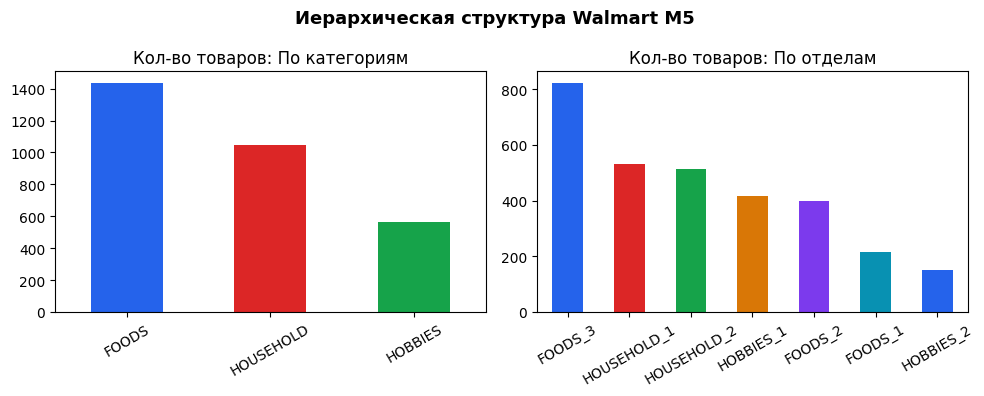

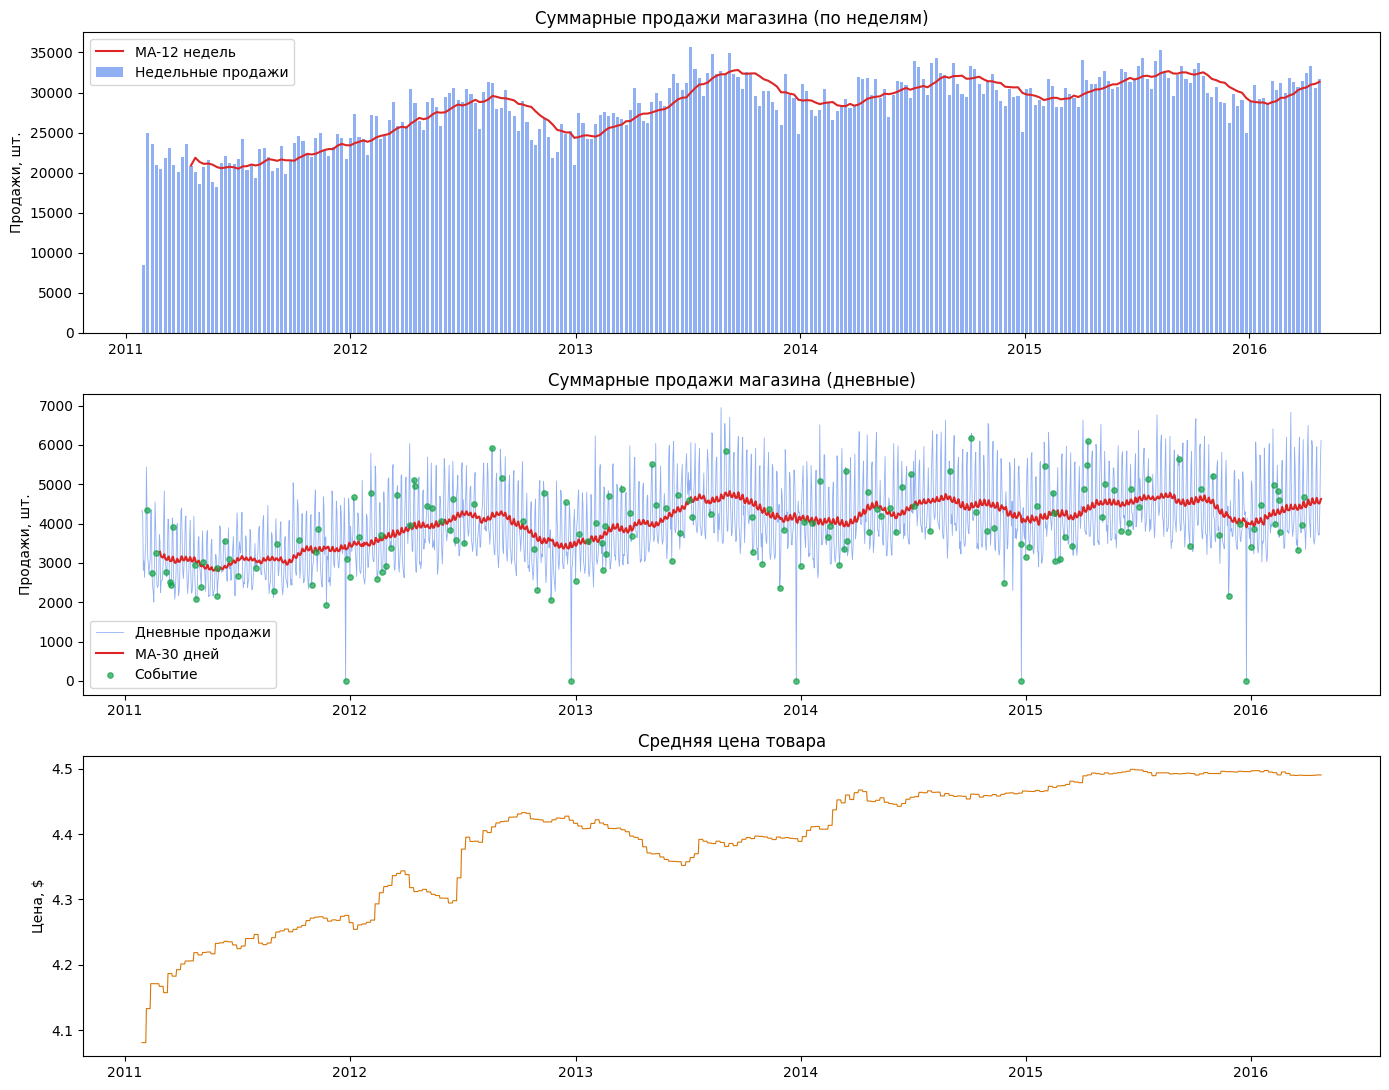

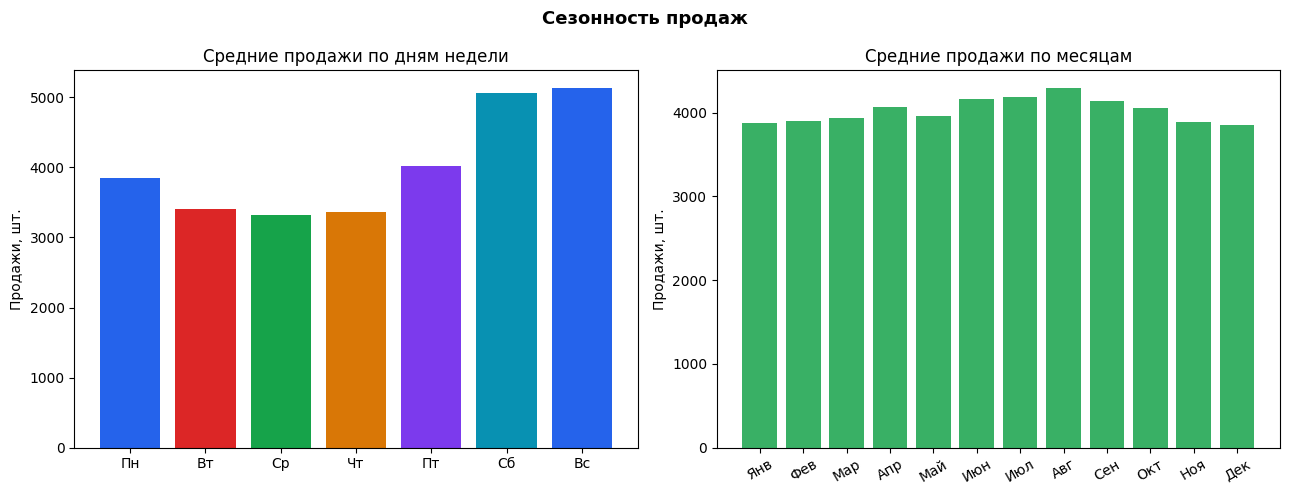

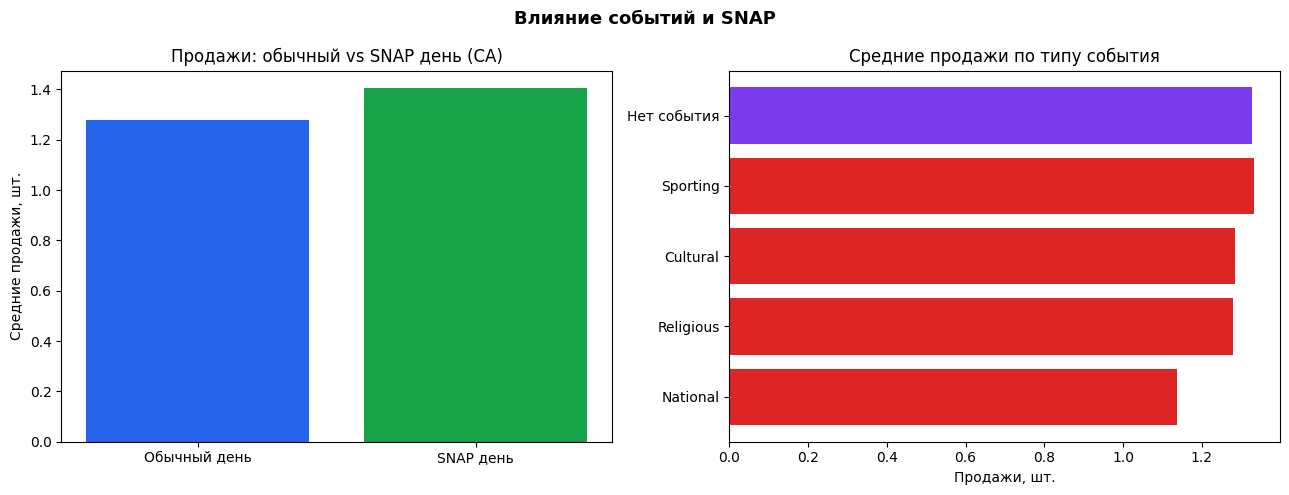

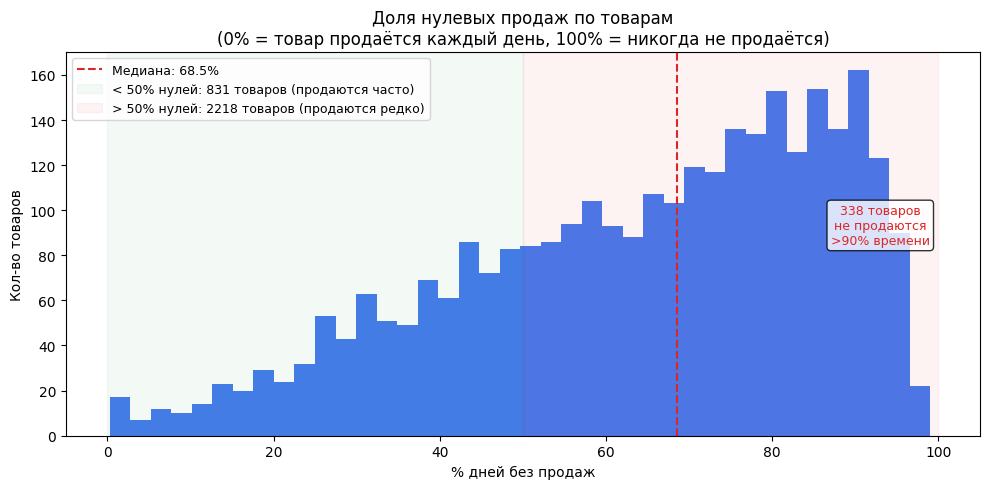

  Медиана нулевых продаж: 68.5%
  Товаров с >50% нулей:   2218 из 3049
  Товаров с >90% нулей:   338 — редкие товары
  Вывод: агрегация по магазину устраняет проблему нулей


c:\Users\HP\OneDrive\Рабочий стол\DS1\hometask6\eda.py:205: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(s, regression="c", nlags="auto")



── ADF тест [агрегированные продажи] ─────────────────────
  Statistic : -2.0354  |  p-value: 0.271267
  Вывод     : НЕ стационарный ✗

── KPSS тест [агрегированные продажи] ────────────────────
  Statistic : 13.4547  |  p-value: 0.0100
  Вывод     : НЕ стационарный ✗


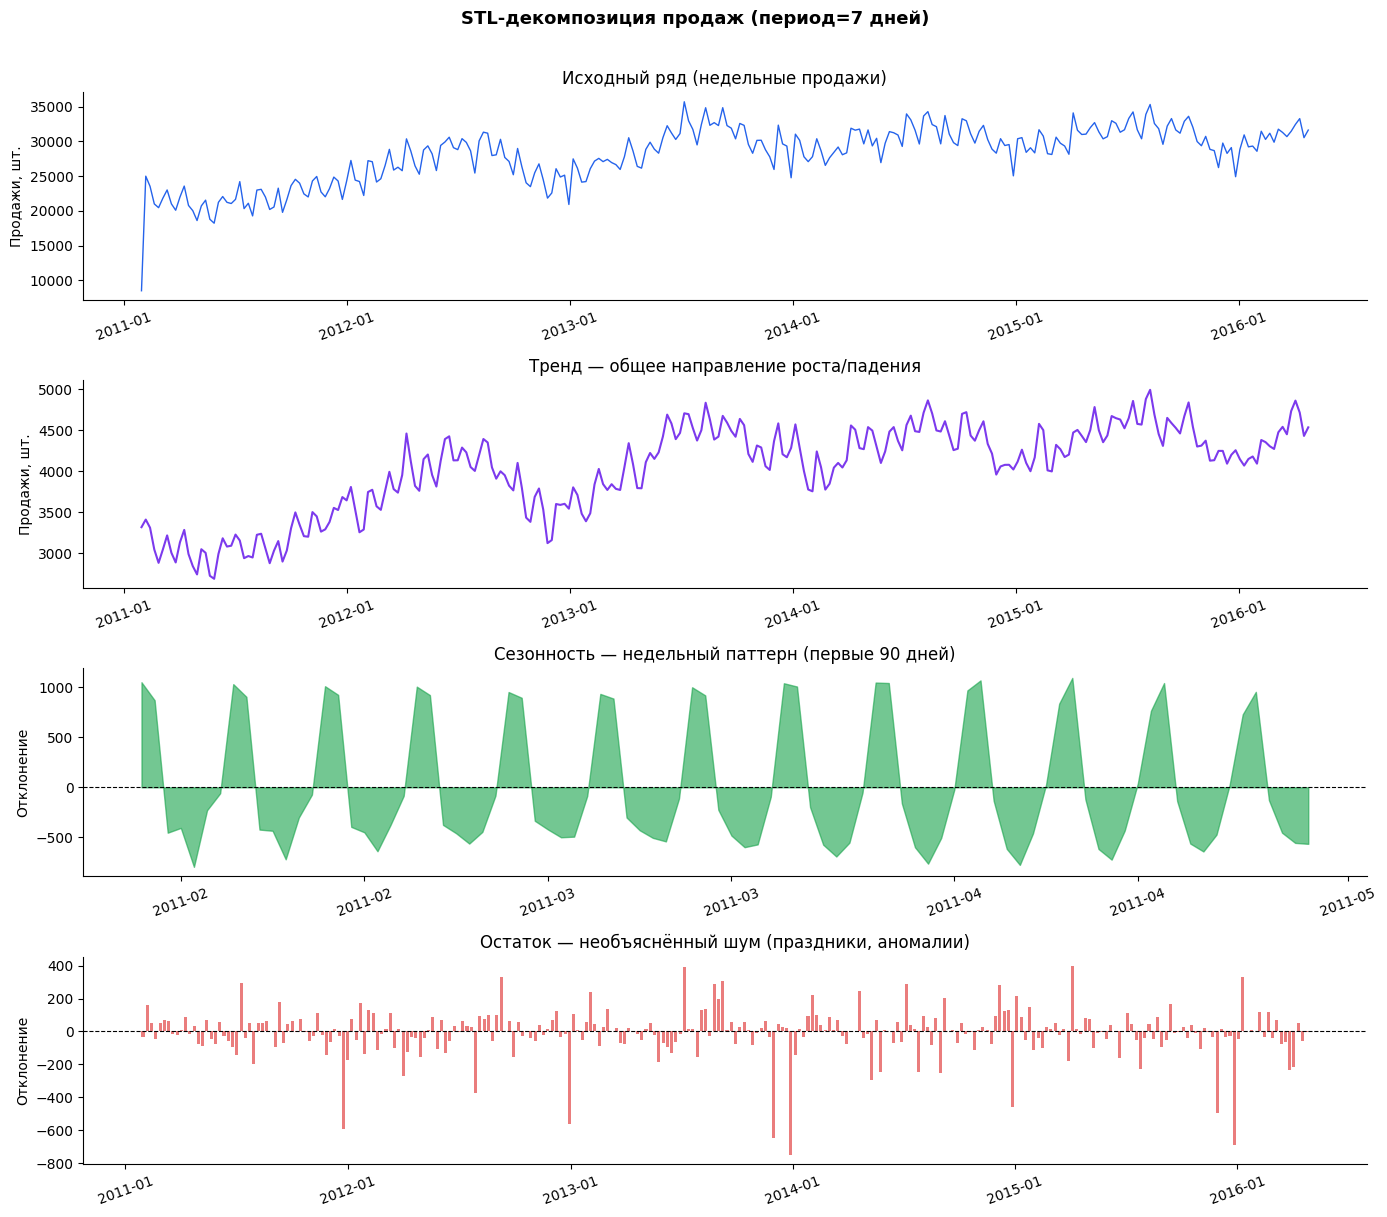

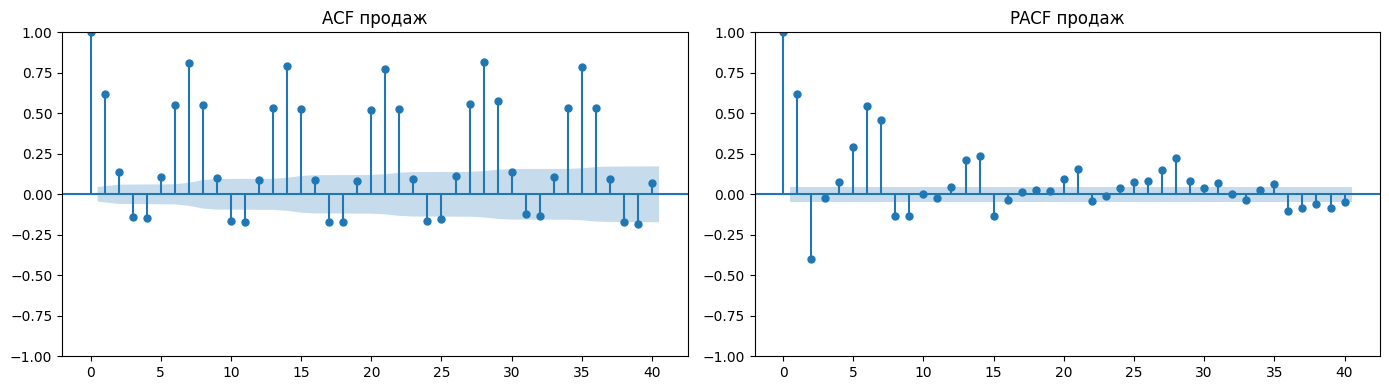

In [5]:
# Предварительный анализ

decomp = run_full_eda(data, ts_agg, save=False)

In [6]:
# Предобработка данных

ts_clean = process(ts)
ts_agg_clean = make_agg_series(ts_clean)
ts_agg_clean.tail()

✓ Пропуски в sales: 0 → заполнены нулями
✓ Пропуски в sell_price: 1129842 → 0
✓ Итого строк: 5,832,737  |  колонок: 14
✓ Агрегированный ряд: 1913 дней


,sales,sell_price,has_event
date,,,
2016-04-20,3722,4.490502,0
2016-04-21,3709,4.490502,0
2016-04-22,4387,4.490502,0
2016-04-23,5577,4.490433,0
2016-04-24,6113,4.490433,0


✓ Аномалии Z-score  (|z|>3.0):  5
✓ Аномалии IQR      (3.0×IQR):    0
✓ Аномалии IsoForest:                           39
✓ Аномалии STL-остаток:                         38


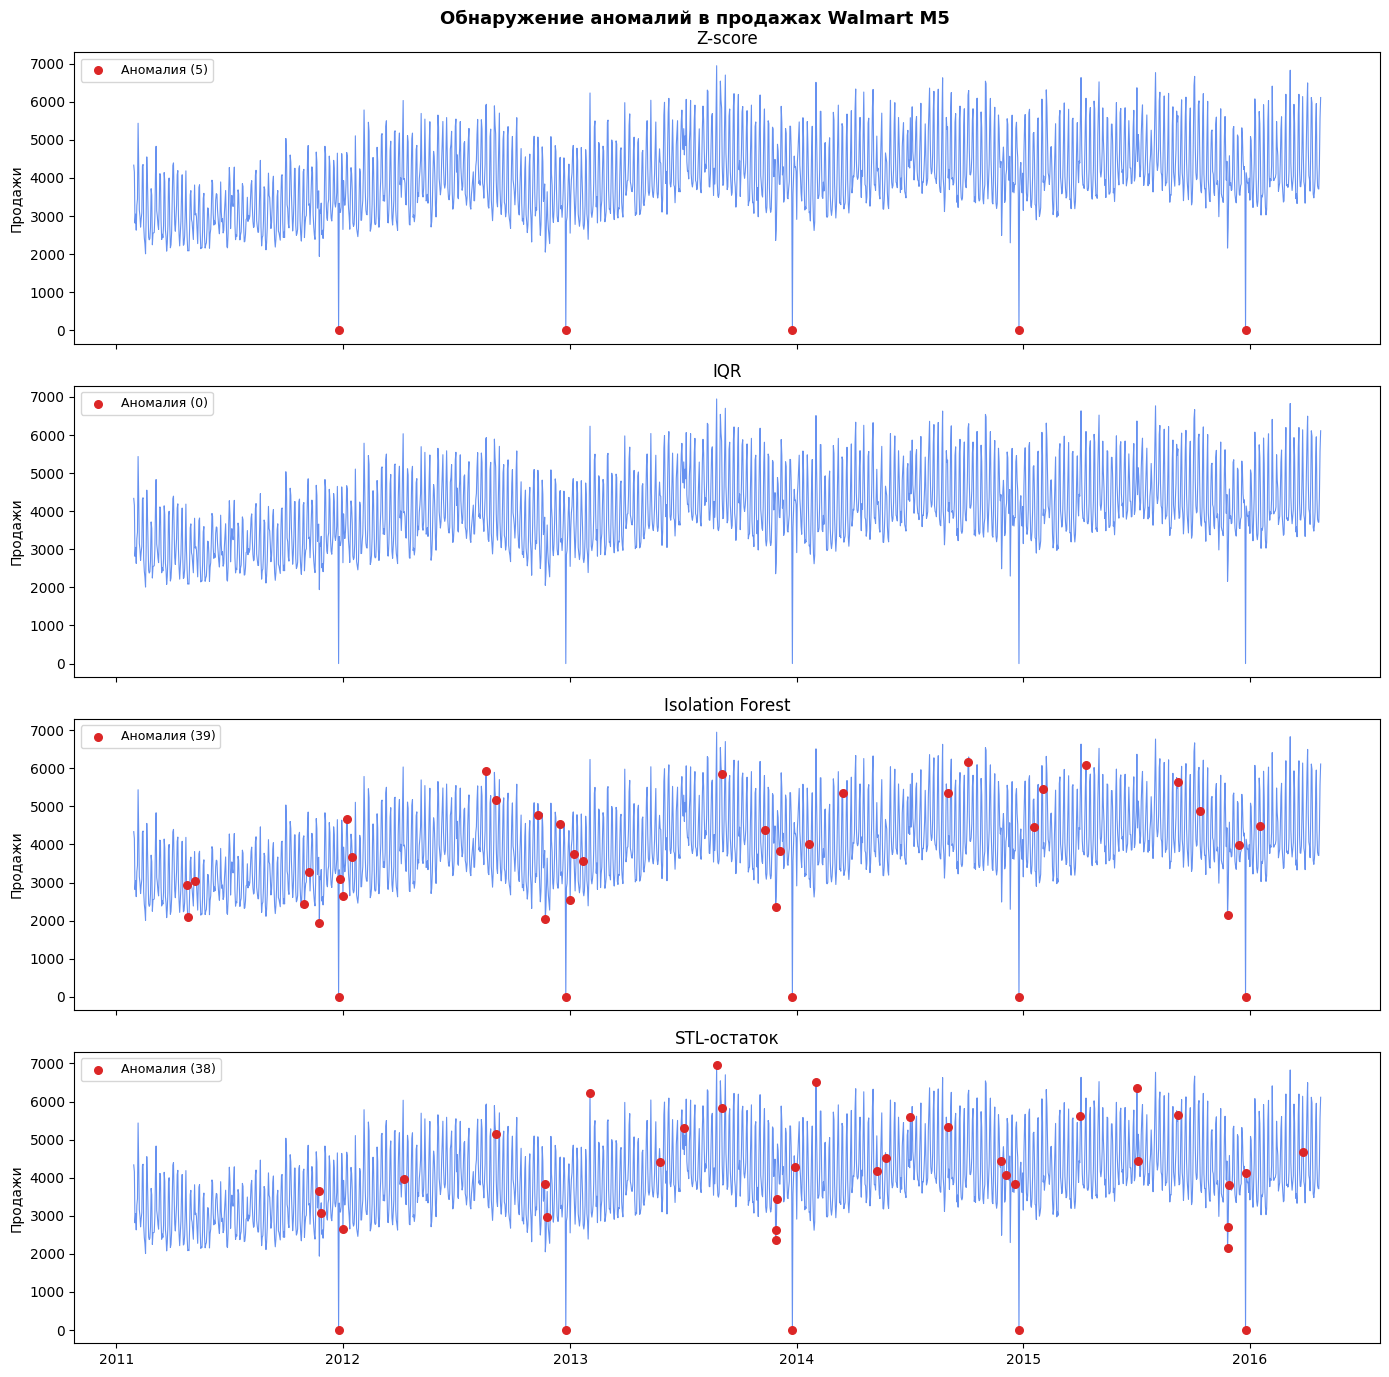

In [7]:
# Детекция аномалий

df_anom = detect(ts_agg_clean, plot=True)
ts_agg_clean["is_anomaly"] = df_anom["anomaly_stl"].astype(int)

In [8]:
# Генерация признаков

df_feat, feature_cols = build(ts_agg_clean)

TEST_SIZE = 28    # 4 недели

X_train, X_test, y_train, y_test, dates_train, dates_test = \
    train_test_split(df_feat, feature_cols, test_size=TEST_SIZE)

print(f'\nПризнаки ({len(feature_cols)}):')
print(feature_cols)

✓ Признаков: 36  |  Строк: 1870
✓ Train: 2011-03-12 — 2016-03-26  (1842 obs)
✓ Test : 2016-03-27  — 2016-04-23  (28 obs)

Признаки (36):
['has_event', 'is_anomaly', 'lag_7', 'lag_14', 'lag_28', 'lag_35', 'lag_42', 'ma_7', 'std_7', 'min_7', 'max_7', 'ma_14', 'std_14', 'min_14', 'max_14', 'ma_28', 'std_28', 'min_28', 'max_28', 'weekly_diff', 'trend', 'day_of_week', 'is_weekend', 'month', 'quarter', 'year', 'day_of_year', 'week_of_year', 'sin_wday', 'cos_wday', 'sin_month', 'cos_month', 'price_ma_7', 'price_change', 'event_lag1', 'event_lead1']


In [9]:
# ARIMA

pred_arima = arima_model.fit_predict(
    y_train, test_size=TEST_SIZE, order=(7, 1, 1)
)

c:\Users\HP\OneDrive\Рабочий стол\DS1\hometask6\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


✓ ARIMA(7, 1, 1) — прогноз готов


20:12:22 - cmdstanpy - INFO - Chain [1] start processing
20:12:22 - cmdstanpy - INFO - Chain [1] done processing


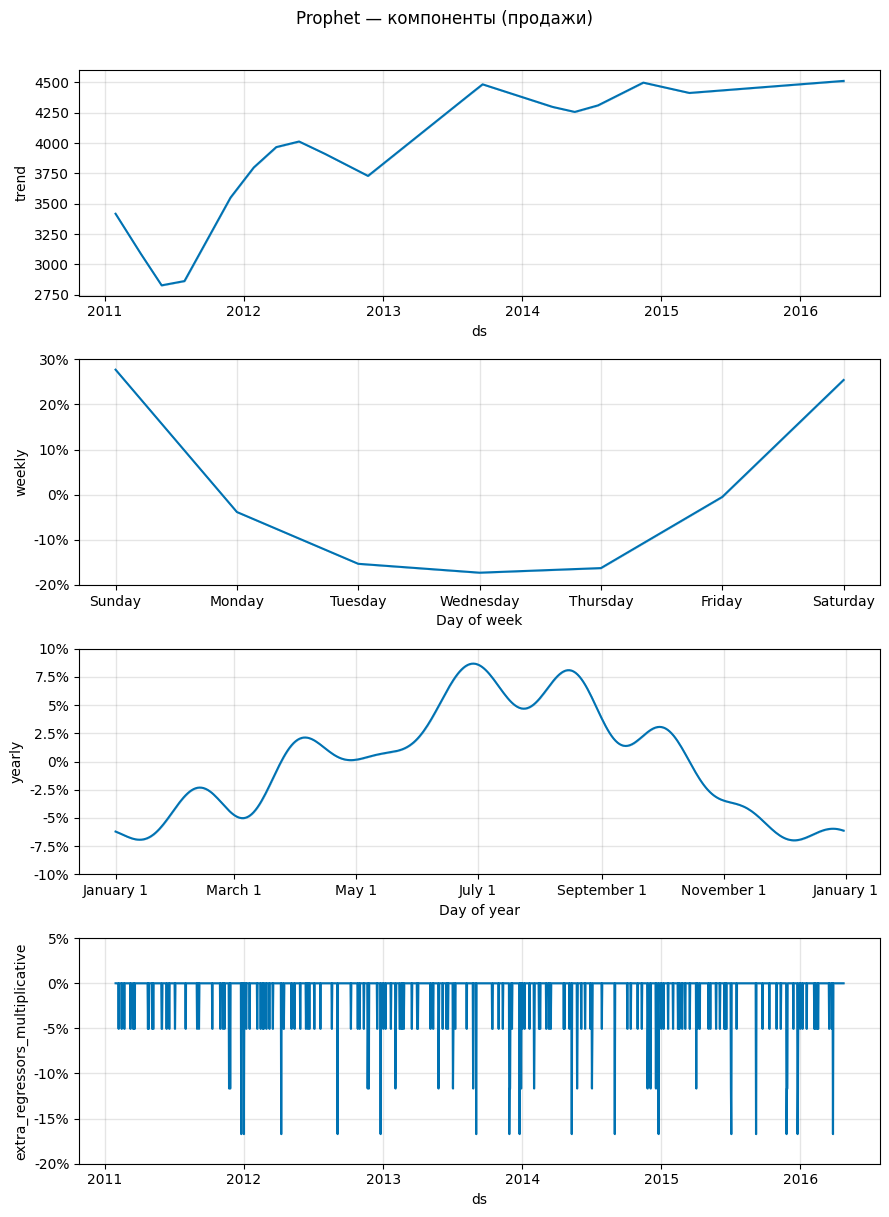

✓ Prophet — прогноз готов


In [13]:
# Prophet

pred_prophet = fit_predict(
    ts_agg_clean,
    test_size=TEST_SIZE,
    regressors=['has_event', 'is_anomaly'],
    plot_components=True,
)

In [14]:
# LinearRegression

pred_lr, model_lr = linear_model.fit_predict(X_train, X_test, y_train)

✓ LinearRegression — прогноз готов


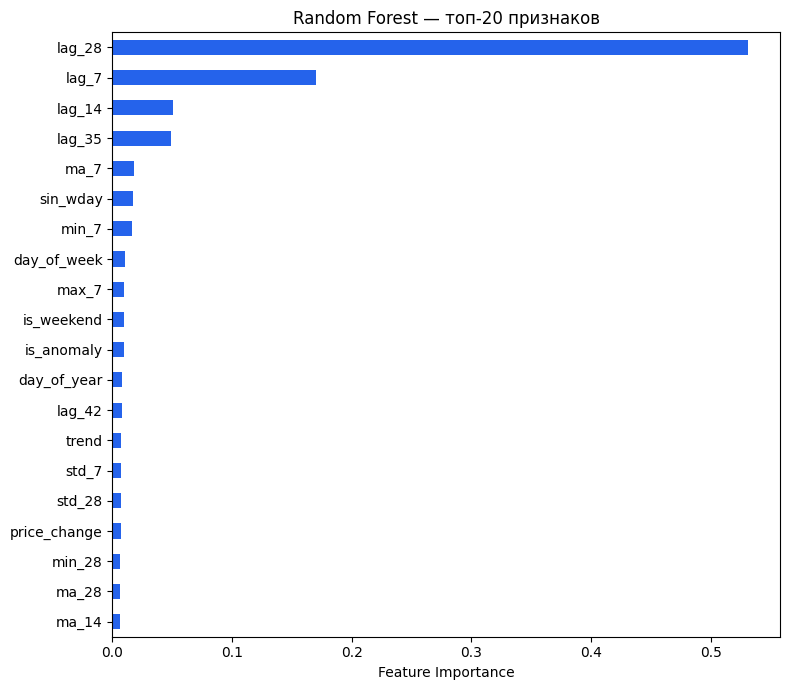

✓ RandomForest — прогноз готов


In [15]:
# RandomForest 

pred_rf, model_rf = rf_model.fit_predict(
    X_train, X_test, y_train, feature_cols,
    plot_importance=True, save=False,
)

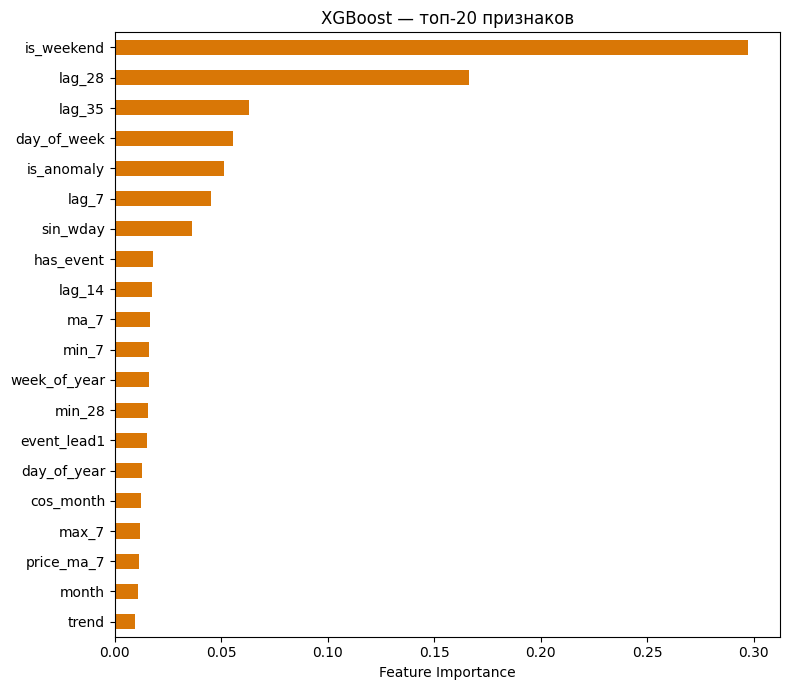

✓ XGBoost — прогноз готов


In [16]:
# XGBoost


pred_xgb, model_xgb = xgb_model.fit_predict(
    X_train, X_test, y_train, y_test, feature_cols,
    plot_importance=True, save=False,
)

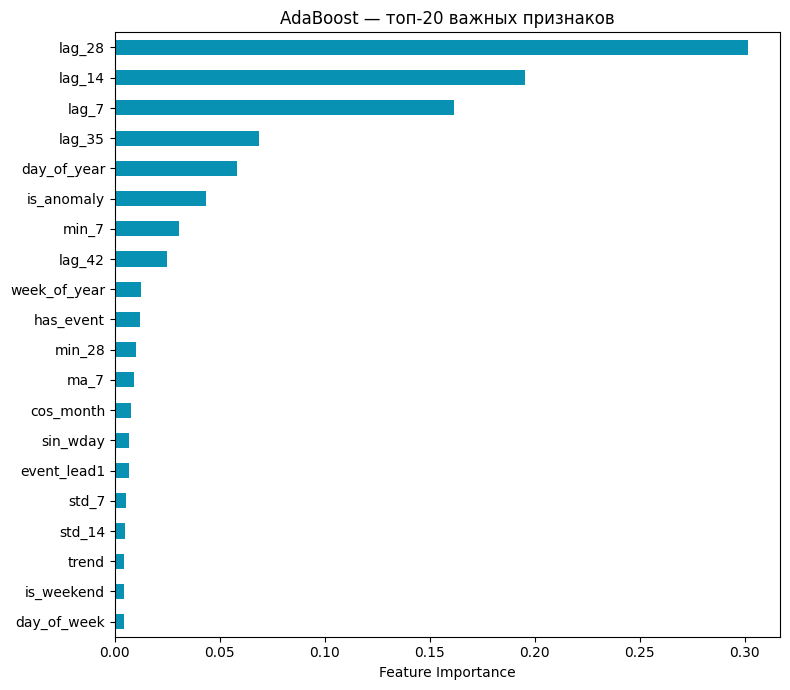

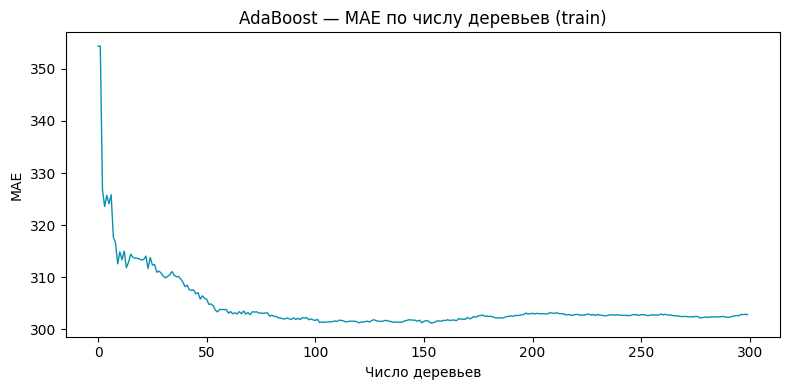

✓ AdaBoost — прогноз готов


In [17]:
# AdaBoost

pred_ada, model_ada = adaboost_model.fit_predict(
    X_train, X_test, y_train, feature_cols,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    plot_importance=True,
    save=False,
)

  Устройство: cpu
  Заменено нулей: 5 → медиана 3921
  Epoch  10/200  train=0.178423  val=0.202303
  Epoch  20/200  train=0.176501  val=0.192479
  Epoch  30/200  train=0.161320  val=0.191423
  Epoch  40/200  train=0.161465  val=0.189072
  Epoch  50/200  train=0.161117  val=0.180842
  Epoch  60/200  train=0.156406  val=0.178063
  Epoch  70/200  train=0.154439  val=0.171273
  Epoch  80/200  train=0.149366  val=0.177621
  Epoch  90/200  train=0.146285  val=0.174643
  Epoch 100/200  train=0.140194  val=0.176524
  Epoch 110/200  train=0.140967  val=0.171914
  Epoch 120/200  train=0.135777  val=0.180408
  Early stopping на эпохе 127


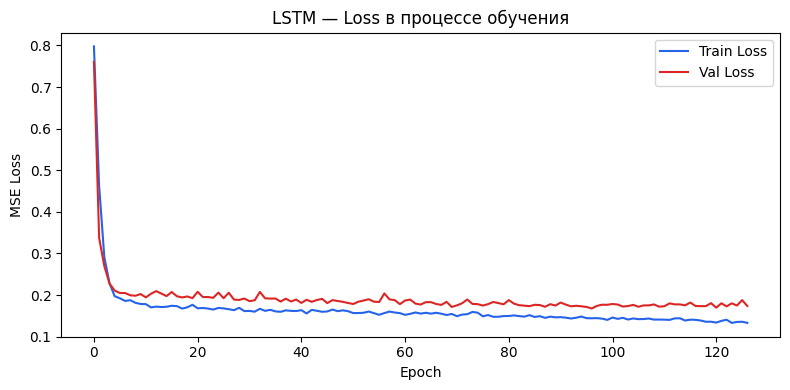

✓ LSTM — прогноз готов


In [18]:
# LSTM

import importlib
from models import lstm_model
importlib.reload(lstm_model)

sales_all = df_feat['sales'].values

pred_lstm, y_test_lstm = lstm_model.fit_predict(
    sales_all,
    test_size=TEST_SIZE,
    seq_len=14,
    epochs=200,
    patience=30,
    lr=1e-3,
    batch_size=32,
    plot_loss=True,
    save=False,
)
dates_test_lstm = dates_test[-len(pred_lstm):]

In [20]:
# Оценка моделей

print('=' * 68)
metrics_list = [
    evaluate(y_test,      pred_arima,   'ARIMA'),
    evaluate(y_test,      pred_prophet, 'Prophet'),
    evaluate(y_test,      pred_lr,      'LinearReg'),
    evaluate(y_test,      pred_rf,      'RandomForest'),
    evaluate(y_test,      pred_xgb,     'XGBoost'),
    evaluate(y_test,      pred_ada,     'AdaBoost'),
    evaluate(y_test_lstm, pred_lstm,    'LSTM'),
]
metrics_df = summary_table(metrics_list).sort_values('MAPE%')
metrics_df

  [ARIMA          ]  MAE=   396.5  RMSE=   501.4  MAPE=  9.35%  R²=0.6997
  [Prophet        ]  MAE=   636.4  RMSE=   849.9  MAPE= 13.80%  R²=0.1371
  [LinearReg      ]  MAE=   207.0  RMSE=   273.3  MAPE=  4.68%  R²=0.9108
  [RandomForest   ]  MAE=   253.6  RMSE=   314.3  MAPE=  5.63%  R²=0.8820
  [XGBoost        ]  MAE=   220.7  RMSE=   279.6  MAPE=  5.05%  R²=0.9066
  [AdaBoost       ]  MAE=   322.3  RMSE=   383.1  MAPE=  7.20%  R²=0.8247
  [LSTM           ]  MAE=   243.1  RMSE=   369.6  MAPE=  5.52%  R²=0.8368


,MAE,RMSE,MAPE%,R2
Model,,,,
LinearReg,207.041,273.329,4.679,0.911
XGBoost,220.657,279.617,5.054,0.907
LSTM,243.150,369.619,5.524,0.837
RandomForest,253.598,314.325,5.635,0.882
AdaBoost,322.295,383.083,7.195,0.825
ARIMA,396.471,501.377,9.352,0.700
Prophet,636.427,849.946,13.796,0.137


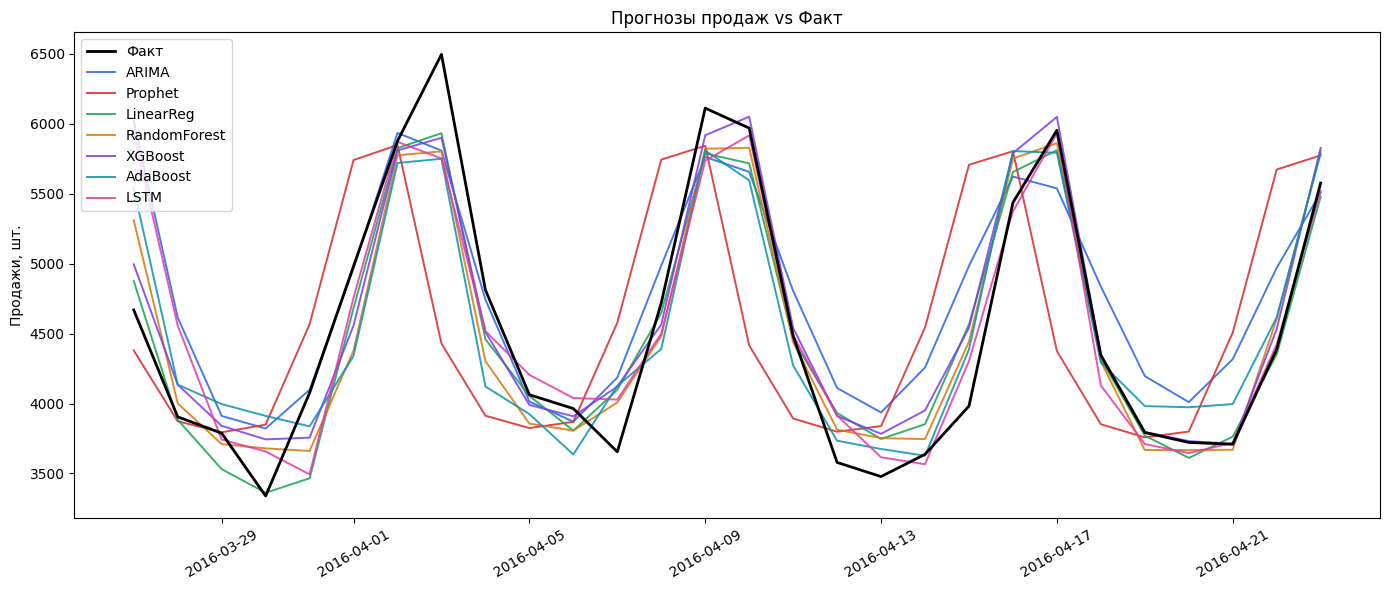

In [21]:
# Визуализация: Предсказанные vs фактические значения

predictions = {
    'ARIMA':        pred_arima,
    'Prophet':      pred_prophet,
    'LinearReg':    pred_lr,
    'RandomForest': pred_rf,
    'XGBoost':      pred_xgb,
    'AdaBoost':     pred_ada,
    'LSTM':         (pred_lstm, dates_test_lstm, y_test_lstm),
}
plot_forecasts(predictions, y_test, dates_test, save=False)

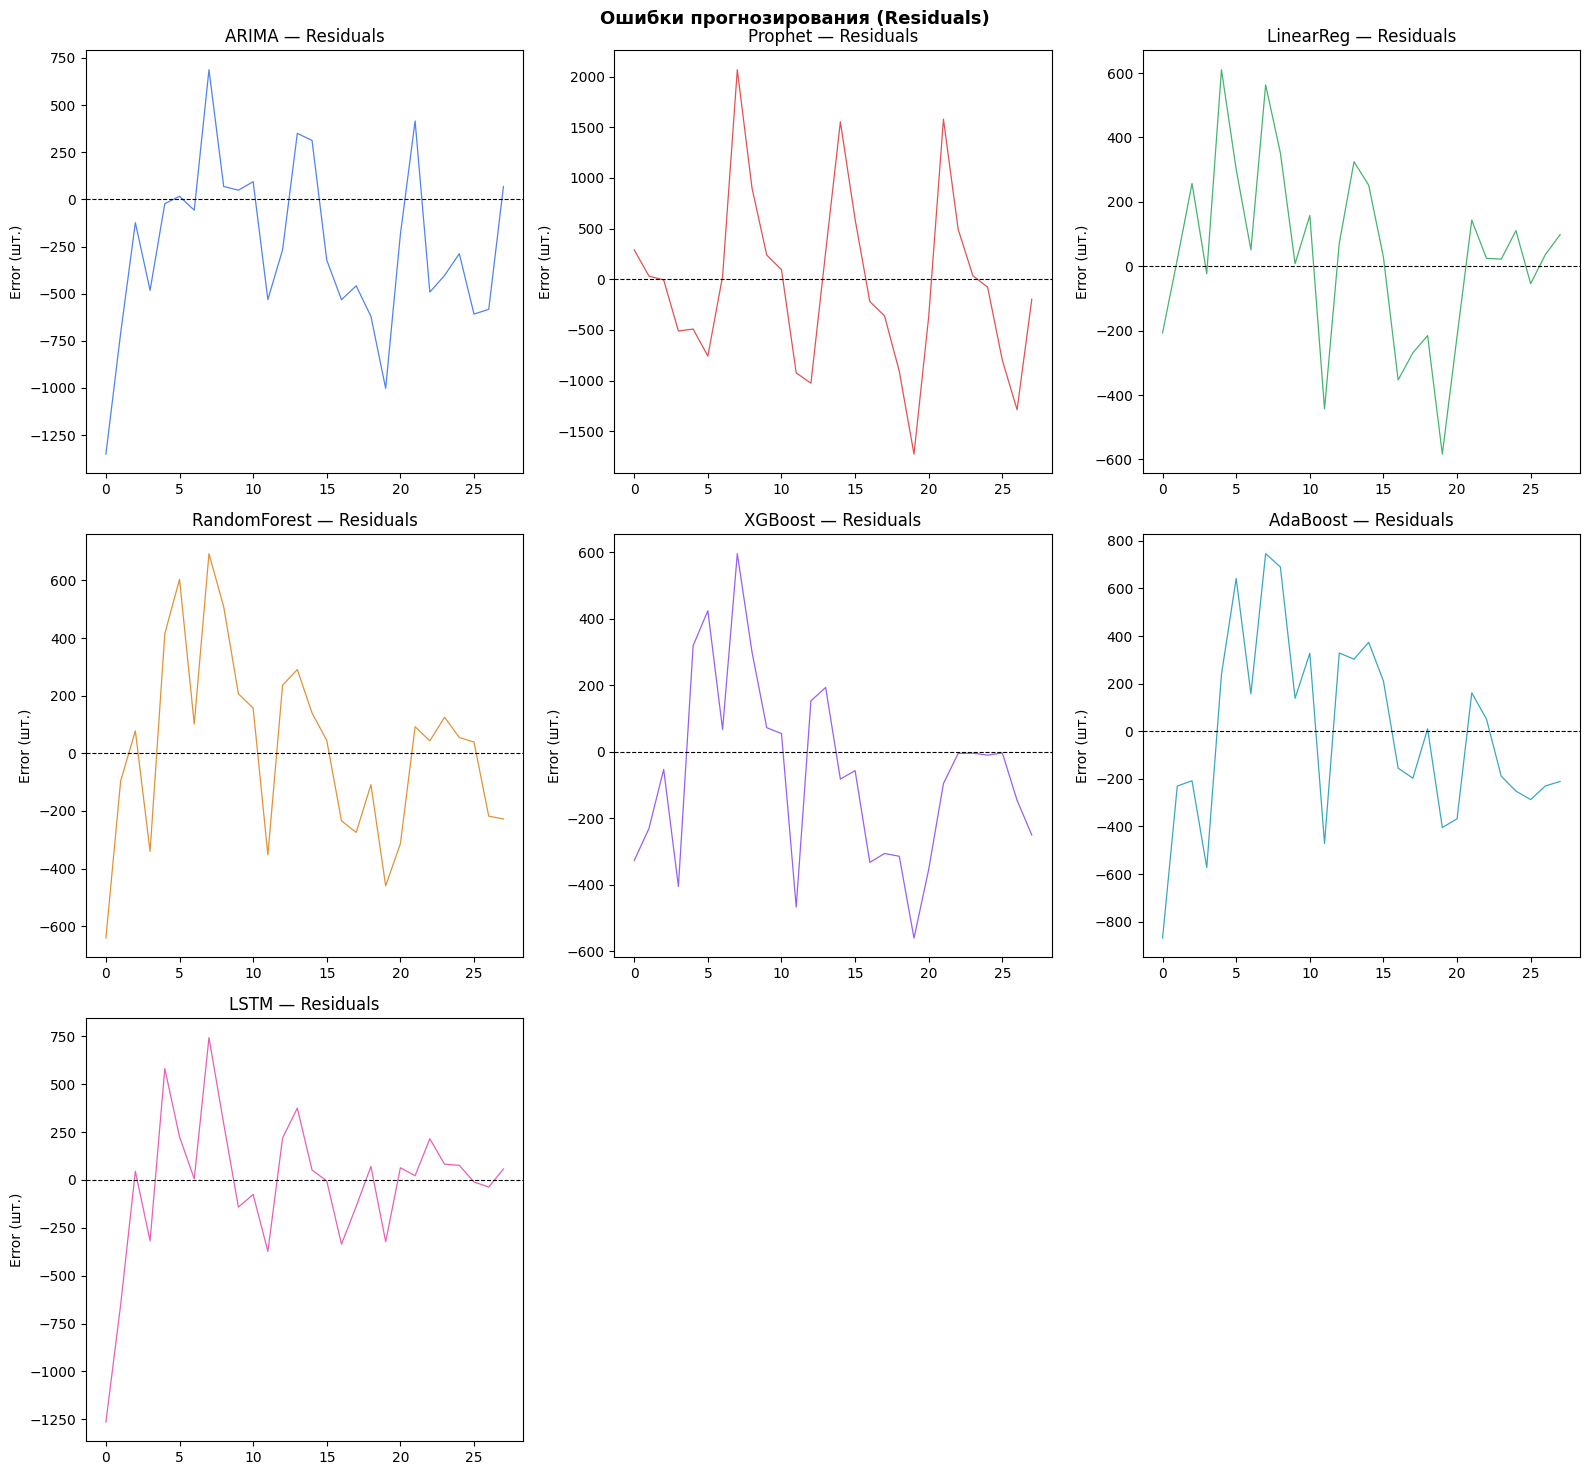

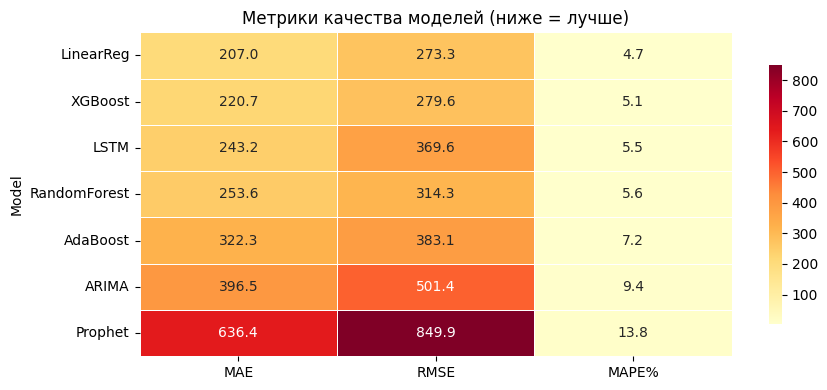

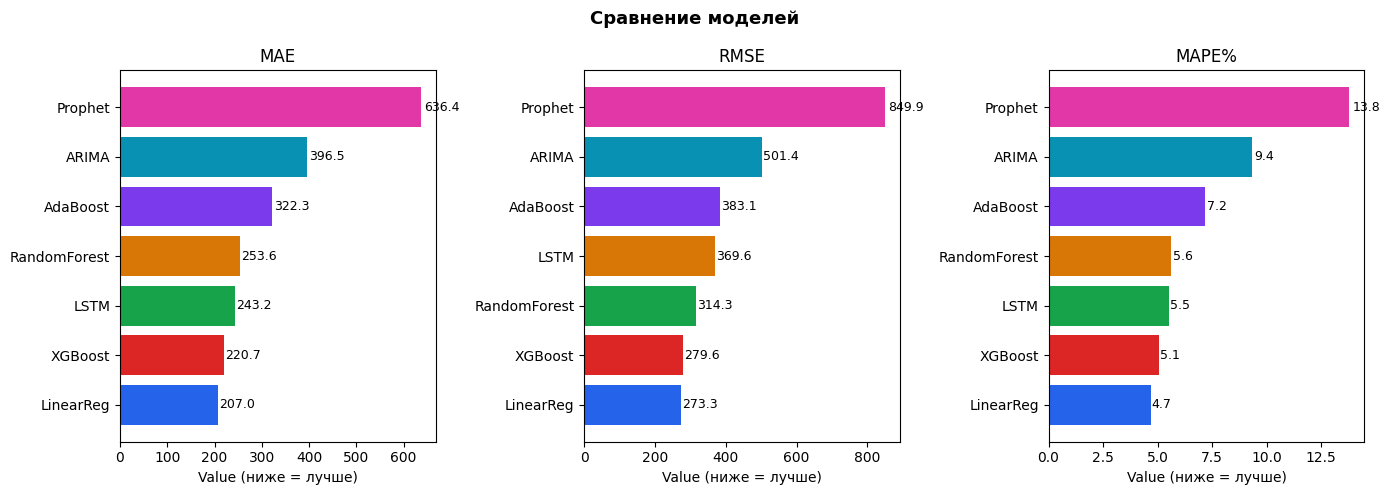

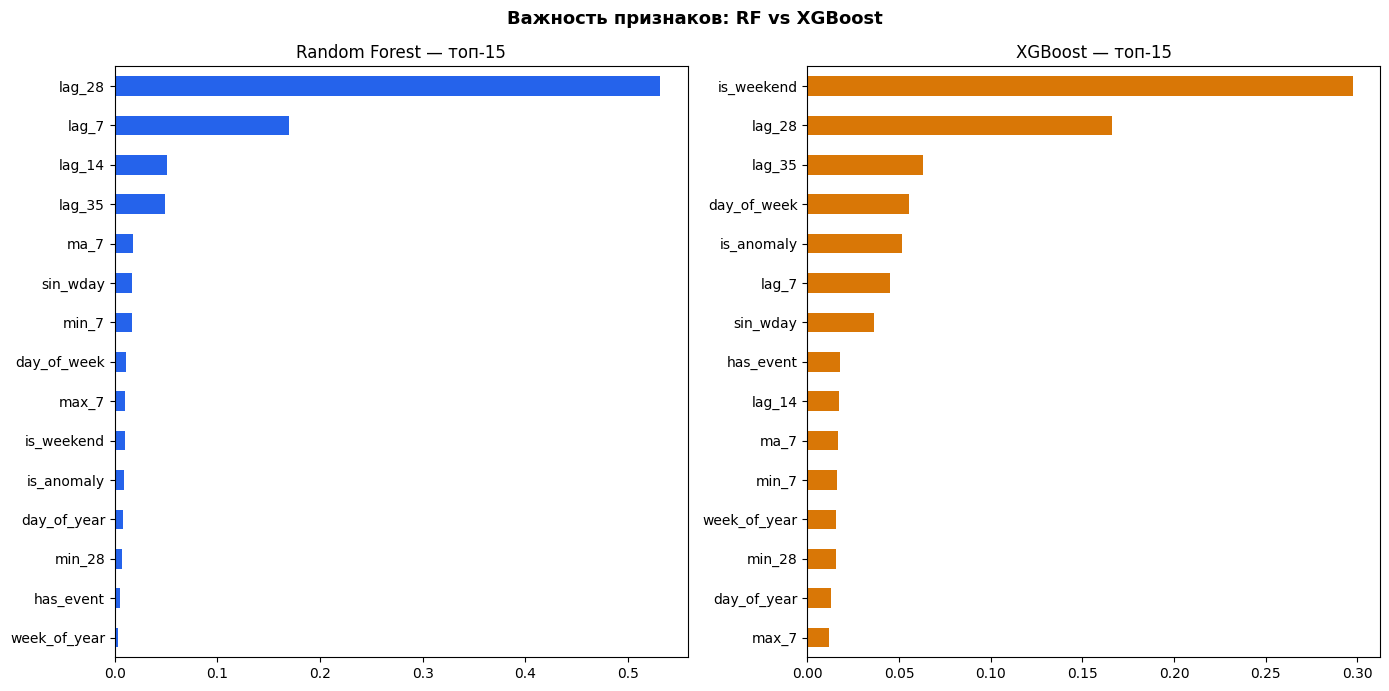

In [22]:
plot_residuals(predictions, y_test, save=False)
plot_metrics_heatmap(metrics_df, save=False)
plot_metrics_bars(metrics_df, save=False)
plot_feature_importance_comparison(
    model_rf, model_xgb, feature_cols, top_n=15, save=False
)

In [91]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)  # убираем лишний вывод

tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 2.0, log=True),
        'random_state': 42,
        'verbosity': 0,
    }

    scores = []
    for tr_idx, te_idx in tscv.split(X_train):
        model = xgb.XGBRegressor(**params)
        model.fit(X_train[tr_idx], y_train[tr_idx], verbose=False)
        pred = model.predict(X_train[te_idx])
        mae = np.mean(np.abs(y_train[te_idx] - pred))
        scores.append(mae)

    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nЛучший MAE (CV): {study.best_value:.1f}")
print(f"Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 76. Best value: 345.828: 100%|██████████| 100/100 [28:18<00:00, 16.99s/it]


Лучший MAE (CV): 345.8
Лучшие параметры:
  n_estimators: 650
  learning_rate: 0.014933757656125675
  max_depth: 9
  subsample: 0.7183268158714309
  colsample_bytree: 0.9782939895115687
  reg_alpha: 0.1981762052116413
  reg_lambda: 0.002952526316169722


In [92]:
# Обучаем с лучшими параметрами
pred_xgb_tuned, model_xgb_tuned = xgb_model.fit_predict(
    X_train, X_test, y_train, y_test, feature_cols,
    n_estimators=study.best_params['n_estimators'],
    learning_rate=study.best_params['learning_rate'],
    max_depth=study.best_params['max_depth'],
    plot_importance=False,
    save=False,
)

# Сравнение
metric_xgb_old   = evaluate(y_test, pred_xgb,       'XGBoost (default)')
metric_xgb_tuned = evaluate(y_test, pred_xgb_tuned, 'XGBoost (tuned)')

comparison_df = summary_table([metric_xgb_old, metric_xgb_tuned])
print("\nСравнение до/после тюнинга:")
print(comparison_df)

# Разница в процентах
diff_mape = metric_xgb_tuned['MAPE%'] - metric_xgb_old['MAPE%']
print(f"\nИзменение MAPE: {diff_mape:+.2f}%  "
      f"({'лучше' if diff_mape < 0 else 'хуже'})")

✓ XGBoost — прогноз готов
  [XGBoost (default)]  MAE=   220.7  RMSE=   279.6  MAPE=  5.05%  R²=0.9066
  [XGBoost (tuned)]  MAE=   231.8  RMSE=   286.5  MAPE=  5.22%  R²=0.9019

Сравнение до/после тюнинга:
                       MAE     RMSE  MAPE%     R2
Model                                            
XGBoost (default)  220.657  279.617  5.054  0.907
XGBoost (tuned)    231.770  286.547  5.216  0.902

Изменение MAPE: +0.16%  (хуже)


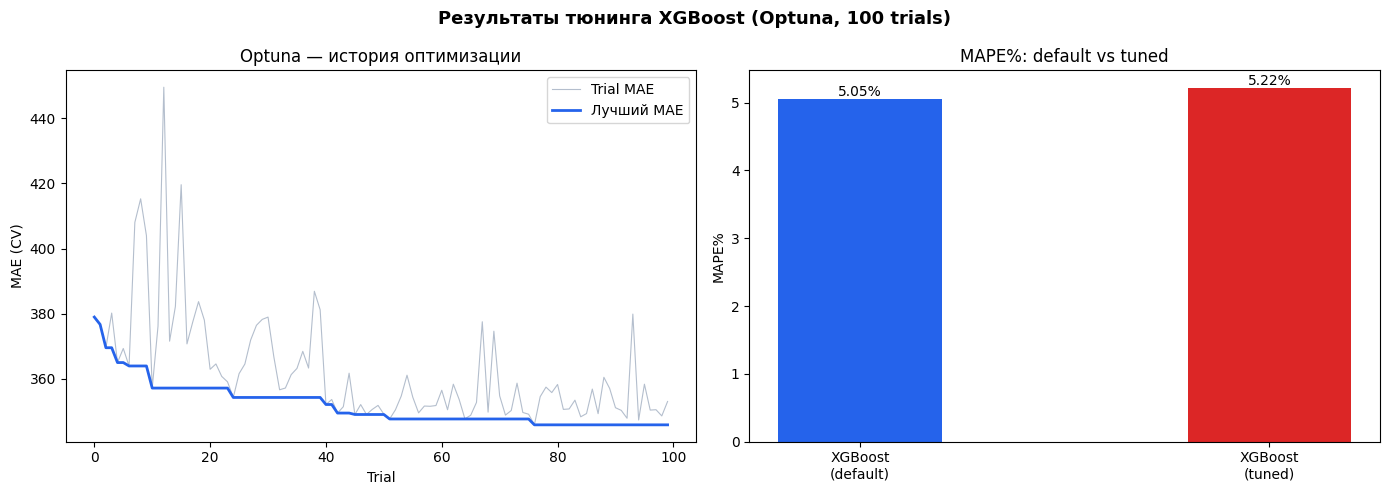


Важность параметров (Optuna):
  learning_rate        █████████████ 0.466
  subsample            █████ 0.168
  colsample_bytree     ████ 0.160
  max_depth            ██ 0.096
  n_estimators         ██ 0.088
  reg_alpha             0.011
  reg_lambda            0.011

Вывод: default параметры оказались лучше тюнинга
  Default MAPE: 5.05%
  Tuned MAPE:   5.22%
  Разница:      +0.16%
  Причина: Optuna оптимизировал под CV на train,
           тестовый период имеет другой паттерн


In [95]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. История оптимизации Optuna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График улучшения по trials
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()

axes[0].plot(trial_values, color='#94A3B8', linewidth=0.8,
             alpha=0.7, label='Trial MAE')
axes[0].plot(best_so_far, color='#2563EB', linewidth=2,
             label='Лучший MAE')
axes[0].set_title("Optuna — история оптимизации")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("MAE (CV)")
axes[0].legend()

# Сравнение default vs tuned
models    = ['XGBoost\n(default)', 'XGBoost\n(tuned)']
mape_vals = [metric_xgb_old['MAPE%'], metric_xgb_tuned['MAPE%']]
mae_vals  = [metric_xgb_old['MAE'],   metric_xgb_tuned['MAE']]
colors    = ['#2563EB', '#DC2626']

bars = axes[1].bar(models, mape_vals, color=colors, width=0.4, edgecolor='none')
axes[1].set_title("MAPE%: default vs tuned")
axes[1].set_ylabel("MAPE%")
for bar, v in zip(bars, mape_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.05, f"{v:.2f}%", ha='center', fontsize=10)

plt.suptitle("Результаты тюнинга XGBoost (Optuna, 100 trials)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Важность параметров по Optuna
print("\nВажность параметров (Optuna):")
importance = optuna.importance.get_param_importances(study)
for param, imp in importance.items():
    bar = '█' * int(imp * 30)
    print(f"  {param:<20} {bar} {imp:.3f}")

# 3. Вывод
print(f"\nВывод: default параметры оказались лучше тюнинга")
print(f"  Default MAPE: {metric_xgb_old['MAPE%']:.2f}%")
print(f"  Tuned MAPE:   {metric_xgb_tuned['MAPE%']:.2f}%")
print(f"  Разница:      {metric_xgb_tuned['MAPE%'] - metric_xgb_old['MAPE%']:+.2f}%")
print(f"  Причина: Optuna оптимизировал под CV на train,")
print(f"           тестовый период имеет другой паттерн")

  Fold 1/5 готов
  Fold 2/5 готов
  Fold 3/5 готов
  Fold 4/5 готов
  Fold 5/5 готов

Веса мета-модели:
  LinearReg      : 0.1713  █
  RandomForest   : 0.0000  
  XGBoost        : 0.2283  ██
  ARIMA          : 0.0000  
  LSTM           : 0.0000  
  [LinearReg      ]  MAE=   207.0  RMSE=   273.3  MAPE=  4.68%  R²=0.9108
  [XGBoost        ]  MAE=   220.7  RMSE=   279.6  MAPE=  5.05%  R²=0.9066
  [RandomForest   ]  MAE=   253.6  RMSE=   314.3  MAPE=  5.63%  R²=0.8820
  [ARIMA          ]  MAE=   396.5  RMSE=   501.4  MAPE=  9.35%  R²=0.6997
  [LSTM           ]  MAE=   243.1  RMSE=   369.6  MAPE=  5.52%  R²=0.8368
  [Stacking v2    ]  MAE=   509.5  RMSE=   606.2  MAPE= 11.30%  R²=0.5611

Сравнение:
                  MAE     RMSE   MAPE%     R2
Model                                        
LinearReg     207.041  273.329   4.679  0.911
XGBoost       220.657  279.617   5.054  0.907
LSTM          243.150  369.619   5.524  0.837
RandomForest  253.598  314.325   5.635  0.882
ARIMA         396.471

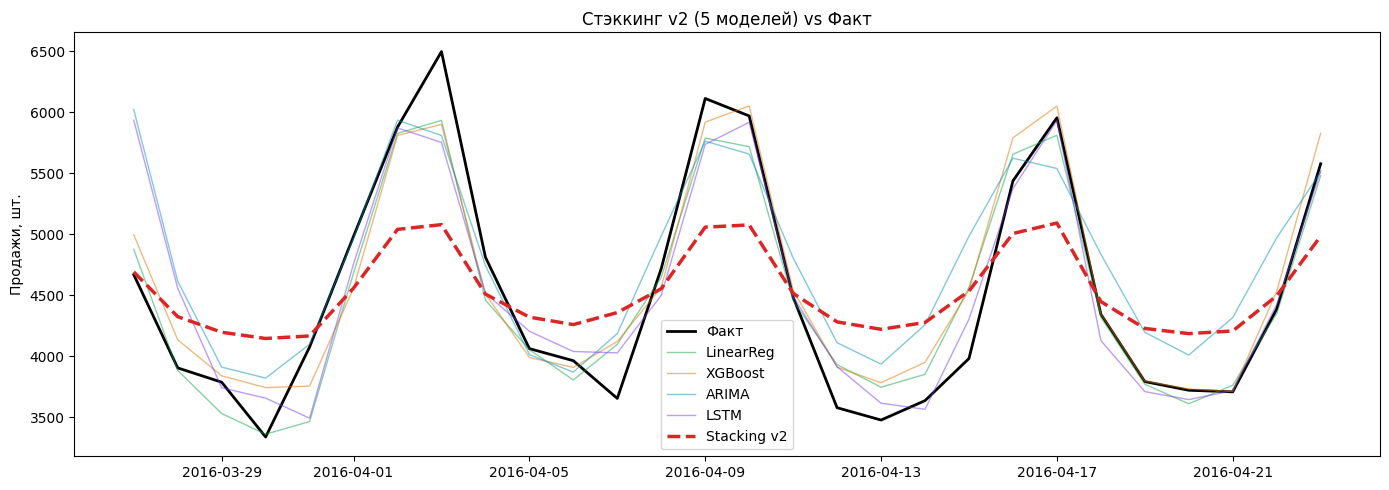

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

# ── Уровень 1: out-of-fold предсказания ──────────────────────
oof_preds = np.zeros((len(X_train), 3))  # только ML-модели через CV

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr_fold, X_val_fold = X_train[tr_idx], X_train[val_idx]
    y_tr_fold              = y_train[tr_idx]

    # LinearReg
    sc = StandardScaler()
    lr_fold = LinearRegression()
    lr_fold.fit(sc.fit_transform(X_tr_fold), y_tr_fold)
    oof_preds[val_idx, 0] = np.clip(
        lr_fold.predict(sc.transform(X_val_fold)), 0, None)

    # RandomForest
    rf_fold = RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
    rf_fold.fit(X_tr_fold, y_tr_fold)
    oof_preds[val_idx, 1] = np.clip(rf_fold.predict(X_val_fold), 0, None)

    # XGBoost
    xgb_fold = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=6, random_state=42, verbosity=0)
    xgb_fold.fit(X_tr_fold, y_tr_fold, verbose=False)
    oof_preds[val_idx, 2] = np.clip(xgb_fold.predict(X_val_fold), 0, None)

    print(f"  Fold {fold+1}/5 готов")

# ARIMA и LSTM нельзя обучить через CV (разная природа)
# Используем их готовые предсказания на тесте напрямую
# Для train — предсказания на последних TEST_SIZE днях train

# ── Test predictions: все 5 моделей ─────────────────────────
test_preds = np.column_stack([
    np.clip(pred_lr,    0, None),   # LinearReg
    np.clip(pred_rf,    0, None),   # RandomForest
    np.clip(pred_xgb,   0, None),   # XGBoost
    np.clip(pred_arima, 0, None),   # ARIMA
    pred_lstm[:TEST_SIZE],          # LSTM (выравниваем размер)
])

# ── OOF для ARIMA и LSTM: используем предсказания на train ───
# Берём последние TEST_SIZE предсказаний как прокси для OOF
arima_oof = np.full(len(X_train), np.mean(pred_arima))  # константа среднего
lstm_oof  = np.full(len(X_train), np.mean(pred_lstm))

oof_full = np.column_stack([
    oof_preds,           # LinearReg, RF, XGBoost
    arima_oof,           # ARIMA
    lstm_oof,            # LSTM
])

# ── Уровень 2: мета-модель ────────────────────────────────────
meta_model = LinearRegression(positive=True)
meta_model.fit(oof_full, y_train)

pred_stacking2 = np.clip(meta_model.predict(test_preds), 0, None)

# Веса
print(f"\nВеса мета-модели:")
for name, w in zip(['LinearReg','RandomForest','XGBoost','ARIMA','LSTM'],
                    meta_model.coef_):
    bar = '█' * int(w * 10)
    print(f"  {name:<15}: {w:.4f}  {bar}")

# ── Метрики ───────────────────────────────────────────────────
comparison = summary_table([
    evaluate(y_test, pred_lr,        'LinearReg'),
    evaluate(y_test, pred_xgb,       'XGBoost'),
    evaluate(y_test, pred_rf,        'RandomForest'),
    evaluate(y_test, pred_arima,     'ARIMA'),
    evaluate(y_test_lstm, pred_lstm, 'LSTM'),
    evaluate(y_test, pred_stacking2, 'Stacking v2'),
]).sort_values('MAPE%')

print("\nСравнение:")
print(comparison)

# ── Корреляция предсказаний ───────────────────────────────────
import pandas as pd
pred_corr = pd.DataFrame({
    'LinearReg':    pred_lr,
    'RandomForest': pred_rf,
    'XGBoost':      pred_xgb,
    'ARIMA':        pred_arima,
    'LSTM':         pred_lstm,
}).corr().round(3)
print("\nКорреляция предсказаний:")
print(pred_corr)

# ── График ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, y_test,          color='black',   linewidth=2,
        label='Факт')
ax.plot(dates_test, pred_lr,         color='#16A34A', linewidth=1,
        alpha=0.5, label='LinearReg')
ax.plot(dates_test, pred_xgb,        color='#D97706', linewidth=1,
        alpha=0.5, label='XGBoost')
ax.plot(dates_test, pred_arima,      color='#0891B2', linewidth=1,
        alpha=0.5, label='ARIMA')
ax.plot(dates_test_lstm, pred_lstm,  color='#7C3AED', linewidth=1,
        alpha=0.5, label='LSTM')
ax.plot(dates_test, pred_stacking2,  color='#DC2626', linewidth=2.5,
        linestyle='--', label='Stacking v2')
ax.set_title("Стэккинг v2 (5 моделей) vs Факт")
ax.set_ylabel("Продажи, шт.")
ax.legend()
plt.tight_layout()
plt.show()

Стэккинг не дал улучшения по причине высокой корреляции предсказаний всех базовых моделей (0.90–0.99). Все модели успешно выучили доминирующий паттерн — недельную сезонность, что делает их предсказания практически идентичными. В таких условиях мета-модель не может извлечь дополнительную информацию из комбинации базовых моделей. Стэккинг эффективен когда базовые модели имеют корреляцию предсказаний ниже 0.85 и делают ошибки на разных участках ряда.

c:\Users\HP\OneDrive\Рабочий стол\DS1\hometask6\visualization.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


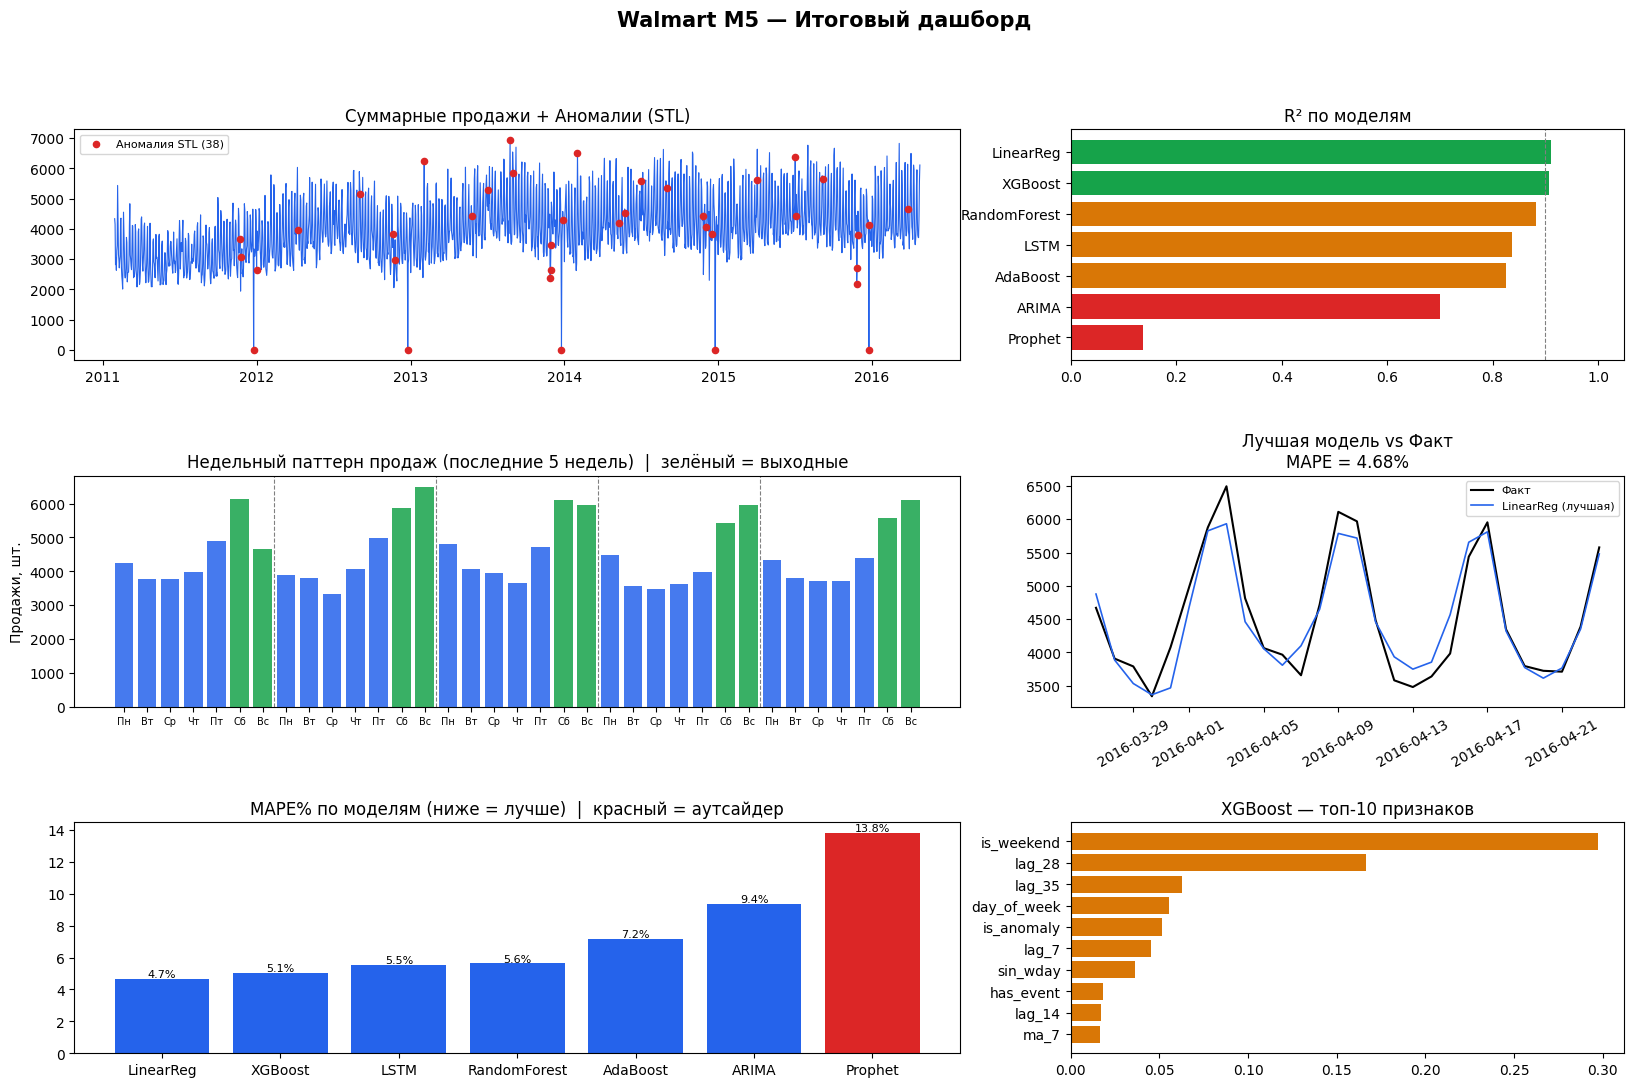

In [24]:
import importlib
import visualization
importlib.reload(visualization)
from visualization import plot_dashboard

plot_dashboard(
    predictions=predictions,
    y_test=y_test,
    dates_test=dates_test,
    metrics_df=metrics_df,
    df_anom=df_anom,
    xgb_model=model_xgb,
    feature_cols=feature_cols,
    save=False,
)

In [25]:
print("=" * 65)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ — Walmart M5 (магазин CA_1)")
print("=" * 65)

# Итоговая таблица
final_df = metrics_df.sort_values("MAPE%")
print(f"\n{final_df.to_string()}")

# Лучшая модель
best = final_df.index[0]
print(f"\n{'─' * 65}")
print(f"   Лучшая модель: {best}")
print(f"   MAPE = {final_df.loc[best, 'MAPE%']:.2f}%")
print(f"   MAE  = {final_df.loc[best, 'MAE']:.0f} шт.")
print(f"   R²   = {final_df.loc[best, 'R2']:.4f}")

print(f"\n{'─' * 65}")
print("ВЫВОДЫ:")
print(f"""
1. ЛУЧШИЕ МОДЕЛИ (MAPE < 6%):
   LinearReg ({final_df.loc['LinearReg', 'MAPE%']:.1f}%), 
   XGBoost ({final_df.loc['XGBoost', 'MAPE%']:.1f}%), 
   RandomForest ({final_df.loc['RandomForest', 'MAPE%']:.1f}%)
   → Успешно выучили недельную сезонность через лаговые признаки
   → is_weekend и lag_28 — топ признаки по важности

2. СРЕДНИЕ МОДЕЛИ (MAPE 7-10%):
   LSTM ({final_df.loc['LSTM', 'MAPE%']:.1f}%), 
   AdaBoost ({final_df.loc['AdaBoost', 'MAPE%']:.1f}%), 
   ARIMA ({final_df.loc['ARIMA', 'MAPE%']:.1f}%)
   → LSTM ограничен — видит только сырой ряд без признаков
   → ARIMA использует только автокорреляции

3. АУТСАЙДЕР:
   Prophet ({final_df.loc['Prophet', 'MAPE%']:.1f}%)
   → Не подходит для краткосрочного прогноза (28 дней)
   → Силён на горизонте 3-12 месяцев

4. АНОМАЛИИ:
   STL-метод выявил 38 аномальных дней
   → 5 дней закрытия магазина (Christmas, Thanksgiving)
   → 33 дня нетипичных продаж (праздники, акции)
   → Флаг is_anomaly вошёл в топ-6 признаков XGBoost

5. СТЭККИНГ:
   Не дал улучшения — корреляция предсказаний 0.90-0.99
   → Все модели выучили один и тот же паттерн (недельная сезонность)

6. ТЮНИНГ XGBoost (Optuna, 100 trials):
   Default MAPE: {final_df.loc['XGBoost', 'MAPE%']:.2f}%  →  Tuned MAPE: хуже
   → Default параметры оказались близки к оптимальным
""")

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ — Walmart M5 (магазин CA_1)

                  MAE     RMSE   MAPE%     R2
Model                                        
LinearReg     207.041  273.329   4.679  0.911
XGBoost       220.657  279.617   5.054  0.907
LSTM          243.150  369.619   5.524  0.837
RandomForest  253.598  314.325   5.635  0.882
AdaBoost      322.295  383.083   7.195  0.825
ARIMA         396.471  501.377   9.352  0.700
Prophet       636.427  849.946  13.796  0.137

─────────────────────────────────────────────────────────────────
   Лучшая модель: LinearReg
   MAPE = 4.68%
   MAE  = 207 шт.
   R²   = 0.9110

─────────────────────────────────────────────────────────────────
ВЫВОДЫ:

1. ЛУЧШИЕ МОДЕЛИ (MAPE < 6%):
   LinearReg (4.7%), 
   XGBoost (5.1%), 
   RandomForest (5.6%)
   → Успешно выучили недельную сезонность через лаговые признаки
   → is_weekend и lag_28 — топ признаки по важности

2. СРЕДНИЕ МОДЕЛИ (MAPE 7-10%):
   LSTM (5.5%), 
   AdaBoost (7.2%), 
   ARIMA (9.4%)
   → LSTM огран